<h1><center>Laboratorio 10: Adivina, Adivinador 🔮</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolas Cabello, Cristopher Urbina

### **Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados**

- Nombre de alumno 1: Hayter Cortés Muñoz     
- Nombre de alumno 2: Robert Collins Dättwyler

### **Link de repositorio de GitHub:** [Repositorio del grupo](https://github.com/HayterCortes/lab-programacion-cientifica-para-ciencia-de-datos)

## Temas a tratar
- Series de Tiempo.
- Predicciones vía `Prophet`.
- Implementar un sistema de recomendación utilizando `surprise`.


### Objetivos principales del laboratorio
- Comprender qué es una serie de tiempo y su estructura.
- Identificar tendencias, estacionalidades e irregularidades.
- Armar un modelo predictivo para la serie.
- Conocer y aplicar sistemas de recomendación.
- Entender estructura y conocer casos de estudio.


In [75]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = 'Dirección donde tiene los archivos en el Drive'
except:
    print('Ignorando conexión drive-colab')

Ignorando conexión drive-colab


In [76]:
# Librerias globales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
import plotly.express as px

# **1. Forecasting (30 puntos)**


## **Prophet**

Prophet es una herramienta open-source de Facebook utilizada para realizar predicciones en series de tiempo. Esta se basa en la descomposición aditiva, donde tendencias no lineales se ajustan junto a la estacionalidad.

En la ecuación de a continuación se puede ver una idea general de los elementos que construyen a un modelo aditivo como lo es Prophet.

\begin{equation}
y(t) = g(t) + s(t) + h(t) + e(t)
\end{equation}

Donde, $g(t)$ hace referencia a las tendencias, que corresponden a cambios graduales en largos periodos de tiempo. $s(t)$ corresponde a la estacionalidad, son cambios periodicos o cortos en el tiempo. $h(t)$ es el efecto que tienen las festividades sobre las predicciones, mientras que e(t) corresponde al error o ruido. Finalmente $y(t)$, es la predicción hecha por el modelo.

Prophet trabaja por defecto con Piece-Wise Lineal Model, este es un modelo de regresión lineal, en el cual se buscan distintas zonas en que la data presente patrones o tendencias lineales, de estas zonas obtiene su regresión y luego las "une" de manera de representar toda la región, como se puede ver en la ecuación siguiente.

\begin{equation}
y(x)=
    \begin{cases}
        η_1 + \beta_1(x-b_1), & b_1 < x  \leqslant b_2 \\
        η_2 + \beta_2(x-b_2), & b_2 < x  \leqslant b_3 \\
        η_3 + \beta_3(x-b_3), & b_3 < x  \leqslant b_3 \\
        ... \\
        η_k + \beta_{nb}(x-b_{nb-1}), & b_{n-1} < x  \leqslant b_{nb} \\
    \end{cases}
\end{equation}

Siendo $b_1$ el primer punto de quiebre en la serie y así hasta el punto $b_{nb}$ correspondiente al último punto de quiebre de la serie con una cantidad $nb$ de puntos.

Para mayor información de Prophet y como utilizarla, pueden ver su [documentación](https://facebook.github.io/prophet/docs/quick_start.html#python-api), donde hay pueden encontrar un pequeño tutorial de la librería.

## **La Factura de Homero**

<center>
<img src ="https://i.makeagif.com/media/7-30-2018/H_ZAY1.gif" width = 500 />

Homero Simpson ha trabajado en la Planta Nuclear de Springfield por más de 20 años como Inspector de Seguridad, pero recientemente el Sr. Burns le ha permitido trabajar desde casa. Aunque le encanta la flexibilidad que esto le otorga, también ha notado un aumento considerable en su consumo energético en el hogar. Con el uso constante de calefacción en invierno y aire acondicionado en verano, Homero está preocupado por cómo afectará esto a su presupuesto en los próximos meses, ya que planea pasar aún más tiempo en casa.

Afortunadamente, gracias a su puesto en la Planta de Energía Nuclear, Homero tiene acceso a los datos de consumo de energía de cada ciudadano en Springfield, por lo que accede a esta información y almacena el consumo de su hogar en un archivo llamado `energia_homero.csv`. Este archivo posee el consumo diario en el hogar de Homero Simpson desde el Junio del 2016 hasta Julio del 2020.

Con esta valiosa información, Homero espera poder predecir su consumo energético y tomar decisiones informadas para ajustar su presupuesto mensual.

Los datos son los siguientes:

* **date**: Fecha de medición.
* **Energy_kWh**: Consumo diario de energía eléctrica en el hogar de Homero (en kWh).

## 1.1 Series de Tiempo [0 puntos]

### Carga de los datos

En primer lugar, cargue los datos históricos del archivo `energia_homero.csv` al entorno de trabajo. Una vez cargados, asegúrense de transformar la columna `date` a formato `datetime`. Además, visualice el consumo de energía en la casa de Homero mediante la librería `plotly`.


**Respuesta**:

In [ ]:
archivo_csv = 'energia_homero.csv'

try:
    df = pd.read_csv(archivo_csv, parse_dates=['date'])
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{archivo_csv}'.")
    df = pd.DataFrame(columns=['date', 'Energy_kWh'])

# Verificación inicial 
if not df.empty:
    print("Datos cargados exitosamente.")
    print("Primeras 5 filas del DataFrame:")
    print(df.head())
    print("\nInformación del DataFrame (verificando tipo de 'date'):")
    df.info()

# Visualización con Plotly  
if not df.empty:
    print("\nGenerando gráfico de la serie de tiempo...")
    
    # Crear el gráfico de líneas interactivo
    fig = px.line(df, 
                  x='date', 
                  y='Energy_kWh', 
                  title='Consumo Diario de Energía en el Hogar de Homero (2016-2020)',
                  labels={'date': 'Fecha', 'Energy_kWh': 'Consumo (kWh)'}
                 )
    
    # Mejorar el layout
    fig.update_layout(
        xaxis_title='Fecha',
        yaxis_title='Consumo de Energía (kWh)',
        title_x=0.5 # Centrar el título
    )
    
    # Mostrar el gráfico
    fig.show()
else:
    print("\nNo se pueden mostrar los datos ni el gráfico porque el DataFrame está vacío.")

Datos cargados exitosamente.
Primeras 5 filas del DataFrame:
        date  Energy_kWh
0 2016-06-01      29.691
1 2016-06-02      28.789
2 2016-06-03      19.247
3 2016-06-04      22.883
4 2016-06-05      25.195

Información del DataFrame (verificando tipo de 'date'):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1498 entries, 0 to 1497
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1498 non-null   datetime64[ns]
 1   Energy_kWh  1498 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 23.5 KB

Generando gráfico de la serie de tiempo...


## 1.2 Controlando la Serie de Tiempo [6 puntos]

<center>
<img src ="https://i.pinimg.com/originals/66/77/88/667788e0b1f08ff1e1cfce11d303b203.gif" width = 500 />

Luego de leer mucho, Homero cree que necesita descomponer la serie de tiempo para poder controlar estos componentes de forma efectiva y lograr que la serie tenga propiedades de una serie estacionaria.

Usted, como buen ciudadano de Springfield, decide ayudar a Homero, el cual le pide que realice lo siguientes pasos:

0. Cree un conjunto de entrenamiento y uno de prueba (a proyectar). Para ello, considere como entrenamiento la información **hasta** el `2020-02-29` y como conjunto de prueba **desde** el `2020-03-01`. [0 puntos]
1. Cree un `Pipeline` que permita obtener una representación de la tendencia de la serie de tiempo, mediante un modelo Lineal. Nombre al pipeline `Pipeline_trend`. [1 punto]
2. Entrene el modelo lineal y luego obtenga predicciones tanto para el conjunto de entrenamiento como para el de prueba (intervalo completo de tiempo). Luego grafique las predicciones y calcule el `Mean Absolute Error` (MAE), tanto para el conjunto de prueba como para el de entrenamiento. [1 punto]
3. Grafique el error (Valor real - Valor predicho) para todo el intervalo de tiempo y responda ¿Hay un comportamiento estacional en la serie? [1 punto]
4.  Cree un `Pipeline` que permita modelar la estacionalidad de la serie temporal mediante términos de Fourier y la represente a través de una Regresión Lineal de la variable objetivo. Nombre a este pipeline `Pipeline_seasonal`. Determine el valor de Periodos `P` y el número de terminos de Fourier `n`. [1 punto]
5. Entrene el nuevo modelo y obtenga predicciones en el intervalo completo de tiempo. Luego grafique y calcule el `MAE` en el conjunto de prueba y en el de entrenamiento. [1 punto]
6. Vuelva a graficar el error y comente los resultados. [1 punto]

**Respuesta**

In [ ]:
# Importaciones adicionales 
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# 0. Crear conjunto de entrenamiento y prueba 

# Definir la fecha de corte
split_date = '2020-02-29'

train_df = df[df['date'] <= split_date].copy()
test_df = df[df['date'] > split_date].copy()

print(f"Datos de entrenamiento: {train_df.shape[0]} filas (hasta {split_date})")
print(f"Datos de prueba: {test_df.shape[0]} filas (desde 2020-03-01)")

# Preparación de X (feature) y y (target) para el modelo de tendencia

df['time_index'] = np.arange(len(df))

# Separar X e y para el entrenamiento
X_train = df.loc[df['date'] <= split_date, 'time_index'].values.reshape(-1, 1)
y_train = df.loc[df['date'] <= split_date, 'Energy_kWh'].values

# Definir el X para el intervalo (para las predicciones)
X_full = df['time_index'].values.reshape(-1, 1)

# 1. Crear el Pipeline de Tendencia 

print("\nCreando el Pipeline_trend...")

# El pipeline contendrá solo el estimador de Regresión Lineal
Pipeline_trend = Pipeline([
    ('linear_model', LinearRegression())
])

print(Pipeline_trend)

# 2. Entrenar el modelo y Obtener Predicciones 

print("Entrenando el modelo de tendencia (Pipeline_trend)...")
Pipeline_trend.fit(X_train, y_train)

print("Generando predicciones de tendencia para el intervalo completo...")
df['trend'] = Pipeline_trend.predict(X_full)

# 2. Graficar las predicciones

print("Generando gráfico de la serie original vs. tendencia...")

df_plot = df.melt(id_vars=['date'], 
                  value_vars=['Energy_kWh', 'trend'], 
                  var_name='Serie', 
                  value_name='Consumo (kWh)')

# Renombrar 'Energy_kWh' 
df_plot['Serie'] = df_plot['Serie'].replace({'Energy_kWh': 'Consumo Real (kWh)',
                                             'trend': 'Tendencia (Predicción)'})

# Crear el gráfico de líneas
fig = px.line(df_plot, 
              x='date', 
              y='Consumo (kWh)', 
              color='Serie', 
              title='Consumo de Energía vs. Tendencia Lineal Estimada',
              labels={'date': 'Fecha'}
             )

# Añadir la línea vertical 
fig.add_vline(x=pd.to_datetime(split_date), 
              line_width=2, 
              line_dash="dot", 
              line_color="grey"
             )


fig.add_annotation(
    x=pd.to_datetime(split_date),
    y=df['Energy_kWh'].max(), 
    text="Separación Train/Test",
    showarrow=True,
    arrowhead=1,
    yshift=10 
)

fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Consumo (kWh)',
    legend_title='Series',
    title_x=0.5 
)

fig.show()

Datos de entrenamiento: 1369 filas (hasta 2020-02-29)
Datos de prueba: 129 filas (desde 2020-03-01)

Creando el Pipeline_trend...
Pipeline(steps=[('linear_model', LinearRegression())])
Entrenando el modelo de tendencia (Pipeline_trend)...
Generando predicciones de tendencia para el intervalo completo...
Generando gráfico de la serie original vs. tendencia...


In [ ]:
# Importar la métrica 
from sklearn.metrics import mean_absolute_error

# 1. Obtener los valores reales (y) del conjunto de prueba 
y_test = df.loc[df['date'] > split_date, 'Energy_kWh'].values

# 2. Obtener las predicciones (y_pred) de la tendencia para ambos conjuntos 
y_pred_train = df.loc[df['date'] <= split_date, 'trend'].values
y_pred_test = df.loc[df['date'] > split_date, 'trend'].values

# 3. Calcular el MAE 
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Resultados del Modelo de Tendencia (Pipeline_trend):")
print(f"MAE en Entrenamiento: {mae_train:.4f} kWh")
print(f"MAE en Prueba:        {mae_test:.4f} kWh")

Resultados del Modelo de Tendencia (Pipeline_trend):
MAE en Entrenamiento: 10.5682 kWh
MAE en Prueba:        8.6558 kWh


In [ ]:
# 1. Calcular el error (Residuales)
df['trend_error'] = df['Energy_kWh'] - df['trend']

print("Calculando el error (residuales) del modelo de tendencia...")
print("Generando gráfico del error...")

# 2. Graficar el error 
fig = px.line(df, 
              x='date', 
              y='trend_error', 
              title='Error del Modelo de Tendencia (Residuales)',
              labels={'date': 'Fecha', 'trend_error': 'Error (Consumo Real - Tendencia)'}
             )

# 3. Añadir líneas de referencia 

fig.add_hline(y=0, 
              line_width=2, 
              line_dash="dash", 
              line_color="red"
             )

fig.add_vline(x=pd.to_datetime(split_date), 
              line_width=2, 
              line_dash="dot", 
              line_color="grey"
             )

fig.add_annotation(
    x=pd.to_datetime(split_date),
    y=df['trend_error'].max(), 
    text="Separación Train/Test",
    showarrow=True,
    arrowhead=1,
    yshift=10 
)

# 4. Mostrar el gráfico
fig.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Error (kWh)',
    title_x=0.5 
)

fig.show()

Calculando el error (residuales) del modelo de tendencia...
Generando gráfico del error...


El gráfico de residuales, obtenido al sustraer la predicción de la tendencia lineal ($g(t)$) del consumo real ($y(t)$), revela información crucial sobre los componentes de la serie. En lugar de presentar un comportamiento de "ruido blanco" (fluctuaciones aleatorias centradas en cero), el error exhibe un **patrón cíclico (anual) fuerte y sistemático**. Se observa que el error es consistentemente positivo durante los peaks de consumo (mediados de año) y negativo o cercano a cero en los valles (principios/finales de año). Esto demuestra de manera concluyente que el modelo de tendencia lineal por sí solo es insuficiente, ya que no ha capturado el componente de estacionalidad. De hecho, al graficar el error $y(t) - g(t)$, lo que se ha logrado es aislar y visualizar la estacionalidad ($s(t)$) más el ruido aleatorio ($e(t)$), confirmando la presencia de un comportamiento estacional dominante que debe ser modelado.

 Se identificaron dos patrones estacionales: una **estacionalidad anual** ($P_1 = 365.25$) para modelar el ciclo dominante de picos de invierno/verano y valles de primavera/otoño, y una **estacionalidad semanal** ($P_2 = 7$) para capturar la variación de consumo entre los días de la semana. Para el número de términos de Fourier ($n$), se seleccionó $n=10$ para el ciclo anual; este valor (que genera 20 *features*) proporciona la flexibilidad necesaria para capturar la forma compleja y no sinusoidal de la estacionalidad anual (peaks agudos y valles amplios), en lugar de una simple onda suave. Para el ciclo semanal, se utilizó $n=3$ (generando 6 *features*), considerado suficiente para modelar el patrón de 7 días.

In [ ]:
# Importaciones adicionales 
from sklearn.base import BaseEstimator, TransformerMixin

# 1. Definir el Transformador de Fourier 

class FourierFeatures(BaseEstimator, TransformerMixin):
    """
    Transformador para crear características de Fourier (seno y coseno) 
    basadas en un índice de tiempo.
    
    seasonal_periods : list of tuples
        Una lista de tuplas (Periodo, n_terminos).
        Ejemplo: [(7, 3), (365.25, 10)]
        (7, 3) -> Estacionalidad semanal (P=7) con n=3 términos.
        (365.25, 10) -> Estacionalidad anual (P=365.25) con n=10 términos.
    """
    def __init__(self, seasonal_periods):
        self.seasonal_periods = seasonal_periods

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        """
        X : array-like, shape (n_samples, 1)
            Debe ser el índice de tiempo (ej. 0, 1, 2, 3...).
        """
        
        if X.ndim == 1:
            X = X.reshape(-1, 1)
            
        all_features = []
        
        for P, n in self.seasonal_periods:
            for i in range(1, n + 1):
                arg = (2 * np.pi * i * X) / P
                
                # Añadir pares de seno y coseno
                all_features.append(np.sin(arg))
                all_features.append(np.cos(arg))
                
        # Combinar todas las características horizontalmente
        return np.hstack(all_features)

# 2. Definir el Pipeline_seasonal 

print("Definiendo los períodos estacionales...")

periods_config = [
    (7, 3),      # Estacionalidad Semanal (6 features: 3 sen, 3 cos)
    (365.25, 10) # Estacionalidad Anual (20 features: 10 sen, 10 cos)
]

print(f"Períodos (P, n): {periods_config}")
print("Total de features a generar:", sum(2 * n for P, n in periods_config))

print("\nCreando el Pipeline_seasonal...")

Pipeline_seasonal = Pipeline([
    # Paso 1: Usar transformador para crear las 26 features de Fourier
    ('fourier_features', FourierFeatures(seasonal_periods=periods_config)),
    
    # Paso 2: Usar Regresión Lineal para encontrar los coeficientes 
    # de esas 26 features.
    ('linear_model', LinearRegression())
])

# Mostrar la estructura del Pipeline
print("\nEstructura del Pipeline_seasonal:")
print(Pipeline_seasonal)

Definiendo los períodos estacionales...
Períodos (P, n): [(7, 3), (365.25, 10)]
Total de features a generar: 26

Creando el Pipeline_seasonal...

Estructura del Pipeline_seasonal:
Pipeline(steps=[('fourier_features',
                 FourierFeatures(seasonal_periods=[(7, 3), (365.25, 10)])),
                ('linear_model', LinearRegression())])


In [ ]:
# 1. Preparar los datos 'y' para este modelo 
y_train_seasonal = df.loc[df['date'] <= split_date, 'trend_error'].values

# 2. Entrenar el Pipeline_seasonal 
print("Entrenando el Pipeline_seasonal...")

# pipeline (Fourier -> LinearRegression)
# X_train es el time_index
# y_train_seasonal es el trend_error
Pipeline_seasonal.fit(X_train, y_train_seasonal)

print("Entrenamiento completado.")

# 3. Obtener predicciones en el intervalo completo 
print("Generando predicciones de estacionalidad para el intervalo completo...")

df['seasonality'] = Pipeline_seasonal.predict(X_full)

# 4. Graficar las predicciones vs. la estacionalidad real 
print("Generando gráfico de estacionalidad (real vs. predicha)...")

df_plot_seasonal = df.melt(id_vars=['date'], 
                           value_vars=['trend_error', 'seasonality'], 
                           var_name='Componente', 
                           value_name='Error/Estacionalidad (kWh)')

df_plot_seasonal['Componente'] = df_plot_seasonal['Componente'].replace({
    'trend_error': 'Estacionalidad Real (Error de Tendencia)',
    'seasonality': 'Estacionalidad Predicha (Modelo)'
})

fig_seasonal = px.line(df_plot_seasonal, 
                       x='date', 
                       y='Error/Estacionalidad (kWh)', 
                       color='Componente',
                       title='Componente Estacional: Real (Error de Tendencia) vs. Predicho',
                       labels={'date': 'Fecha'})

# Añadir línea de separación 
fig_seasonal.add_vline(x=pd.to_datetime(split_date), 
                       line_width=2, 
                       line_dash="dot", 
                       line_color="grey")

fig_seasonal.add_annotation(
    x=pd.to_datetime(split_date),
    y=df['trend_error'].max(), 
    text="Separación Train/Test",
    showarrow=True,
    arrowhead=1,
    yshift=10
)

fig_seasonal.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Consumo (kWh)',
    legend_title='Componente',
    title_x=0.5
)

fig_seasonal.show()

# 5. Calcular el MAE 

print("\nCalculando MAE del modelo de estacionalidad...")

# Valores Reales (el error de tendencia)
y_true_train_seasonal = df.loc[df['date'] <= split_date, 'trend_error'].values
y_true_test_seasonal = df.loc[df['date'] > split_date, 'trend_error'].values

# Predicciones (la estacionalidad modelada)
y_pred_train_seasonal = df.loc[df['date'] <= split_date, 'seasonality'].values
y_pred_test_seasonal = df.loc[df['date'] > split_date, 'seasonality'].values

# Calcular MAE
mae_train_seasonal = mean_absolute_error(y_true_train_seasonal, y_pred_train_seasonal)
mae_test_seasonal = mean_absolute_error(y_true_test_seasonal, y_pred_test_seasonal)

print(f"Resultados del Modelo de Estacionalidad (Pipeline_seasonal):")
print(f"MAE en Entrenamiento (sobre el error): {mae_train_seasonal:.4f} kWh")
print(f"MAE en Prueba (sobre el error):        {mae_test_seasonal:.4f} kWh")

Entrenando el Pipeline_seasonal...
Entrenamiento completado.
Generando predicciones de estacionalidad para el intervalo completo...
Generando gráfico de estacionalidad (real vs. predicha)...



Calculando MAE del modelo de estacionalidad...
Resultados del Modelo de Estacionalidad (Pipeline_seasonal):
MAE en Entrenamiento (sobre el error): 5.4664 kWh
MAE en Prueba (sobre el error):        6.1932 kWh


In [ ]:
# 1. Calcular el Error Final (Residuales del modelo completo) 

df['final_error'] = df['trend_error'] - df['seasonality']

print("Calculando el error final (residuales) del modelo combinado...")
print("Generando gráfico del error final...")

# 2. Graficar el Error Final 
fig_final_error = px.line(df, 
                          x='date', 
                          y='final_error', 
                          title='Error Final del Modelo (Residuales tras Trend + Seasonality)',
                          labels={'date': 'Fecha', 'final_error': 'Error (kWh)'}
                         )

# 3. Añadir líneas de referencia 

fig_final_error.add_hline(y=0, 
                          line_width=2, 
                          line_dash="dash", 
                          line_color="red"
                         )

fig_final_error.add_vline(x=pd.to_datetime(split_date), 
                          line_width=2, 
                          line_dash="dot", 
                          line_color="grey"
                         )

fig_final_error.add_annotation(
    x=pd.to_datetime(split_date),
    y=df['final_error'].max(), 
    text="Separación Train/Test",
    showarrow=True,
    arrowhead=1,
    yshift=10 
)

# 4. Mostrar el gráfico 
fig_final_error.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Error (kWh)',
    title_x=0.5 
)

fig_final_error.show()

Calculando el error final (residuales) del modelo combinado...
Generando gráfico del error final...


El gráfico del error final, que representa los residuales tras sustraer tanto el componente de tendencia ($g(t)$) como el componente de estacionalidad modelado ($s(t)$) de los datos reales ($y(t)$), demuestra el éxito de la descomposición de la serie. A diferencia del gráfico de residuales anterior, el **fuerte patrón estacional anual ha sido eliminado**, ya que la línea de error no presenta los ciclos predecibles. El resultado es un gráfico que se asemeja al **ruido blanco**, donde los valores fluctúan de manera aleatoria alrededor de la línea cero. Indica que los modelos de tendencia y estacionalidad han capturado toda la información estructural y predecible de la serie, aislando únicamente el componente irregular ($e(t)$) o aleatorio.

## 1.3 Un Consejo para Homero [6 puntos]

<center>
<img src ="https://media.tenor.com/sjbvGMLZiDkAAAAM/the-simpsons-homner-simpson.gif" width = 400 />

Homero al observar los resultados obtenidos, se mostró conforme y decidió no seguir averiguando al respecto. Usted, como buen amigo y utilizando sus recientes conocimientos en Forecast, le sugiere a Homero utilizar **Prophet**, una herramienta de modelado de series de tiempo que incluye descomposición de tendencias y estacionalidad, así como la capacidad de incorporar regresores adicionales. Usted le explica a Homero que Prophet es especialmente útil para realizar pronósticos cuando hay patrones estacionales y que podría mejorar los resultados que ha obtenido hasta ahora.

Homero, algo agotado debido al exhaustivo estudio que hizo para entender como funciona esta herramienta, le solicita ayuda para implementar Prophet y evaluar si puede obtener mejores resultados en sus predicciones de consumo energético.

Dado esto, Homero le pide que realice los siguientes pasos:

1. Instale y cargue Prophet a su entorno de trabajo. Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh` por `y`, en los conjuntos de entrenamiento y de prueba. [1 punto]
2. Cree y ajuste el modelo Prophet con sus datos de entrenamiento. Luego prepare el dataset de predicciones con su set de prueba y realice las predicciones. `Nota:` Le puede ser útil este [Enlace](https://facebook.github.io/prophet/docs/quick_start.html#python-api) [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo. Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie? [1 punto]

In [84]:
# librerias extras
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

**Respuesta:**

In [ ]:
# 1. Importar Prophet y Preparar los Datos 

print("Paso 1: Preparando datos para Prophet (renombrando a 'ds' e 'y')...")

prophet_train_df = df.loc[df['date'] <= split_date, ['date', 'Energy_kWh']].rename(
    columns={'date': 'ds', 'Energy_kWh': 'y'}
)

prophet_test_df = df.loc[df['date'] > split_date, ['date', 'Energy_kWh']].rename(
    columns={'date': 'ds', 'Energy_kWh': 'y'}
)

print(f"Datos de entrenamiento para Prophet: {prophet_train_df.shape[0]} filas")
print(f"Datos de prueba para Prophet: {prophet_test_df.shape[0]} filas")
print("\nPrimeras filas del set de entrenamiento de Prophet:")
print(prophet_train_df.head())


# 2. Crear, Ajustar y Predecir con Prophet 

print("\nPaso 2: Creando y ajustando el modelo Prophet...")

m = Prophet()

# Ajustar el modelo con los datos de entrenamiento
m.fit(prophet_train_df)

print("Ajuste (fit) completado.")

# Preparar el DataFrame para predicciones.
future_df = df[['date']].rename(columns={'date': 'ds'})

print("Generando predicciones para el intervalo completo...")
# Realizar predicciones sobre todas las fechas
forecast = m.predict(future_df)

print("Predicciones generadas.")

# 3. Graficar Predicciones y Componentes 

print("\nPaso 3: Generando gráficos de Prophet...")

# Gráfico 1: Predicción (Forecast)
print("Generando prophet_forecast.png ...")
fig1 = m.plot(forecast)
ax1 = fig1.gca()
ax1.axvline(pd.to_datetime(split_date), color='grey', linestyle='--', lw=2)
plt.savefig('prophet_forecast.png')
plt.close(fig1) 

# Gráfico 2: Componentes (Trend, Weekly, Yearly)
print("Generando prophet_components.png ...")
fig2 = m.plot_components(forecast)
plt.savefig('prophet_components.png')
plt.close(fig2) 

print("Gráficos guardados.")


# 4. Calcular el MAE 

print("\nPaso 4: Calculando el MAE del modelo Prophet...")

df_prophet_full = df[['date', 'Energy_kWh']].rename(columns={'date': 'ds', 'Energy_kWh': 'y'})

# Unir los valores reales (y) con los predichos (yhat)
comparison_df = pd.merge(df_prophet_full, forecast[['ds', 'yhat']], on='ds')

# Separar en train y test
split_datetime = pd.to_datetime(split_date)

train_comparison = comparison_df[comparison_df['ds'] <= split_datetime]
test_comparison = comparison_df[comparison_df['ds'] > split_datetime]

# Calcular MAE
mae_train_prophet = mean_absolute_error(train_comparison['y'], train_comparison['yhat'])
mae_test_prophet = mean_absolute_error(test_comparison['y'], test_comparison['yhat'])

print(f"Resultados del Modelo Prophet:")
print(f"MAE en Entrenamiento: {mae_train_prophet:.4f} kWh")
print(f"MAE en Prueba:        {mae_test_prophet:.4f} kWh")


# 5. Graficar el Error (Residuales) 

print("\nPaso 5: Generando gráfico del error (residuales) de Prophet...")

# Calcular el error en todo el intervalo
comparison_df['error'] = comparison_df['y'] - comparison_df['yhat']

# Graficar el error 
fig_error_prophet = px.line(comparison_df, 
                            x='ds', 
                            y='error', 
                            title='Error del Modelo Prophet (Residuales)',
                            labels={'ds': 'Fecha', 'error': 'Error (Real - Predicho) kWh'}
                           )

fig_error_prophet.add_hline(y=0, 
                            line_width=2, 
                            line_dash="dash", 
                            line_color="red"
                           )

fig_error_prophet.add_vline(x=split_datetime, 
                            line_width=2, 
                            line_dash="dot", 
                            line_color="grey"
                           )

fig_error_prophet.add_annotation(
    x=split_datetime,
    y=comparison_df['error'].max(), 
    text="Separación Train/Test",
    showarrow=True,
    arrowhead=1,
    yshift=10 
)

fig_error_prophet.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Error (kWh)',
    title_x=0.5 
)

fig_error_prophet.show()

Paso 1: Preparando datos para Prophet (renombrando a 'ds' e 'y')...
Datos de entrenamiento para Prophet: 1369 filas
Datos de prueba para Prophet: 129 filas

Primeras filas del set de entrenamiento de Prophet:
          ds       y
0 2016-06-01  29.691
1 2016-06-02  28.789
2 2016-06-03  19.247
3 2016-06-04  22.883
4 2016-06-05  25.195

Paso 2: Creando y ajustando el modelo Prophet...
Ajuste (fit) completado.
Generando predicciones para el intervalo completo...
Predicciones generadas.

Paso 3: Generando gráficos de Prophet...
Generando prophet_forecast.png ...


c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



Generando prophet_components.png ...


c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



Gráficos guardados.

Paso 4: Calculando el MAE del modelo Prophet...
Resultados del Modelo Prophet:
MAE en Entrenamiento: 4.8205 kWh
MAE en Prueba:        4.9340 kWh

Paso 5: Generando gráfico del error (residuales) de Prophet...


El modelo alcanzó un **Error Absoluto Medio (MAE) de 4.9340 kWh** en el conjunto de prueba, superando significativamente al MAE de 6.19 kWh del modelo manual. El gráfico de error (residuales) valida este resultado, ya que ahora presenta un comportamiento de **ruido blanco** fluctuando aleatoriamente alrededor de cero. Esto indica que el modelo ha capturado de buena manera toda la información estructural, dejando solo el error aleatorio. En cuanto a la pregunta sobre el **comportamiento estacional, la respuesta es si**. La evidencia es el gráfico de componentes de Prophet, que aisló visualmente un fuerte patrón **anual** (peaks en invierno/verano) y **semanal**, demostrando que estos ciclos son fundamentales para la predicción.

## 1.4 Incluyendo Regresores [5 puntos]

<center>
<img src ="https://i.redd.it/64hwjftunjjd1.gif" width = 400 />

Con los nuevos resultados obtenidos del modelo Prophet, usted le aconseja a Homero que puede mejorar sus predicciones al incluir regresores en el modelo, es decir, variables adicionales que pueden influir en la variable objetivo, en este caso, el consumo energético. Homero encuentra que es una buena idea y va en busca de ayuda donde el Profesor Frink, un destacado Científico de Springfield. Para suerte de Homero, Frink tenía un estudio reciente que registra las condiciones climáticas en Springfield, en el mismo intervalo de tiempo en que Homero disponía de los datos de consumo eléctrico. Con esta nueva información, usted le recomienda a Homero que podrían utilizar esta información meteorológica proporcionada como variables exógenas al modelo.

Sin embargo, al no comprender bien la importancia de los regresores, Homero decide confiar en sus capacidades y le pide que, por favor, incluya estas variables en el modelo para evaluar su impacto en las predicciones.

Para ello, usted debe:
0. Seleccionar las variables exógenas a utilizar del archivo `datos_frink.csv`. Añada estas variables a sus conjuntos de entrenamiento y prueba mediante `merge`. [0 puntos]
1. Cree el modelo Prophet e incluya los regresores (variables exógenas) al modelo. Luego realice el entrenamiento. **Hint**: Utilice el método `.add_regressor()`. Mas información en el siguiente [Enlace](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors). [2 puntos]
2. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
3. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. Analice sus resultados. [1 punto]
4. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y de prueba. ¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero? [1 punto]

Los datos del dataset de Frink son los siguientes:

* **date**: Fecha de medición.
* **Temp_max**: Temperatura máxima registrada durante el día (en °F).
* **Temp_avg**: Temperatura promedio registrada durante el día (en °F).
* **Temp_min**: Temperatura mínima registrada durante el día (en °F).
* **Dew_max**: Punto de rocío máximo registrado durante el día (en °F).
* **Dew_avg**: Punto de rocío promedio registrado durante el día (en °F).
* **Dew_min**: Punto de rocío mínimo registrado durante el día (en °F).
* **Hum_max**: Humedad máxima registrada durante el día (en porcentaje).
* **Hum_avg**: Humedad promedio registrada durante el día (en porcentaje).
* **Hum_min**: Humedad mínima registrada durante el día (en porcentaje).
* **Wind_max**: Velocidad máxima del viento registrada durante el día (en millas por hora, mph).
* **Wind_avg**: Velocidad promedio del viento registrada durante el día (en millas por hora, mph).
* **Wind_min**: Velocidad mínima del viento registrada durante el día (en millas por hora, mph).
* **Press_max**: Presión atmosférica máxima registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_avg**: Presión atmosférica promedio registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_min**: Presión atmosférica mínima registrada durante el día (en pulgadas de mercurio, Hg).

**Respuesta:**

Paso 0: Cargando y Uniendo Datos de Regresores (datos_frink.csv) 
Regresores seleccionados: ['Temp_avg', 'Hum_avg', 'Wind_avg']
Datos de entrenamiento (con regresores) listos: (1369, 10)
Datos futuros (con regresores) listos: (1498, 4)

 Paso 1: Creando, Añadiendo Regresores y Ajustando Modelo 
Añadiendo regresor: Temp_avg
Añadiendo regresor: Hum_avg
Añadiendo regresor: Wind_avg
Ajustando (fit) el modelo con regresores...
Ajuste completado.

 Paso 2: Graficando Predicciones y Componentes 
Generando gráfico de predicción (prophet_forecast_reg.png)...


c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



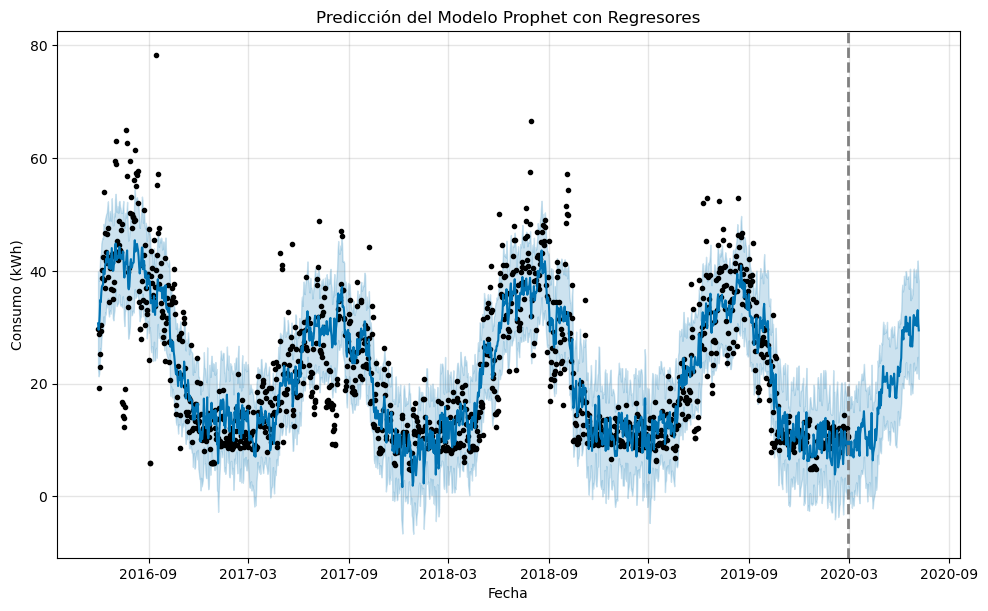

Generando gráfico de componentes (prophet_components_reg.png)...


c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\anaconda3\env

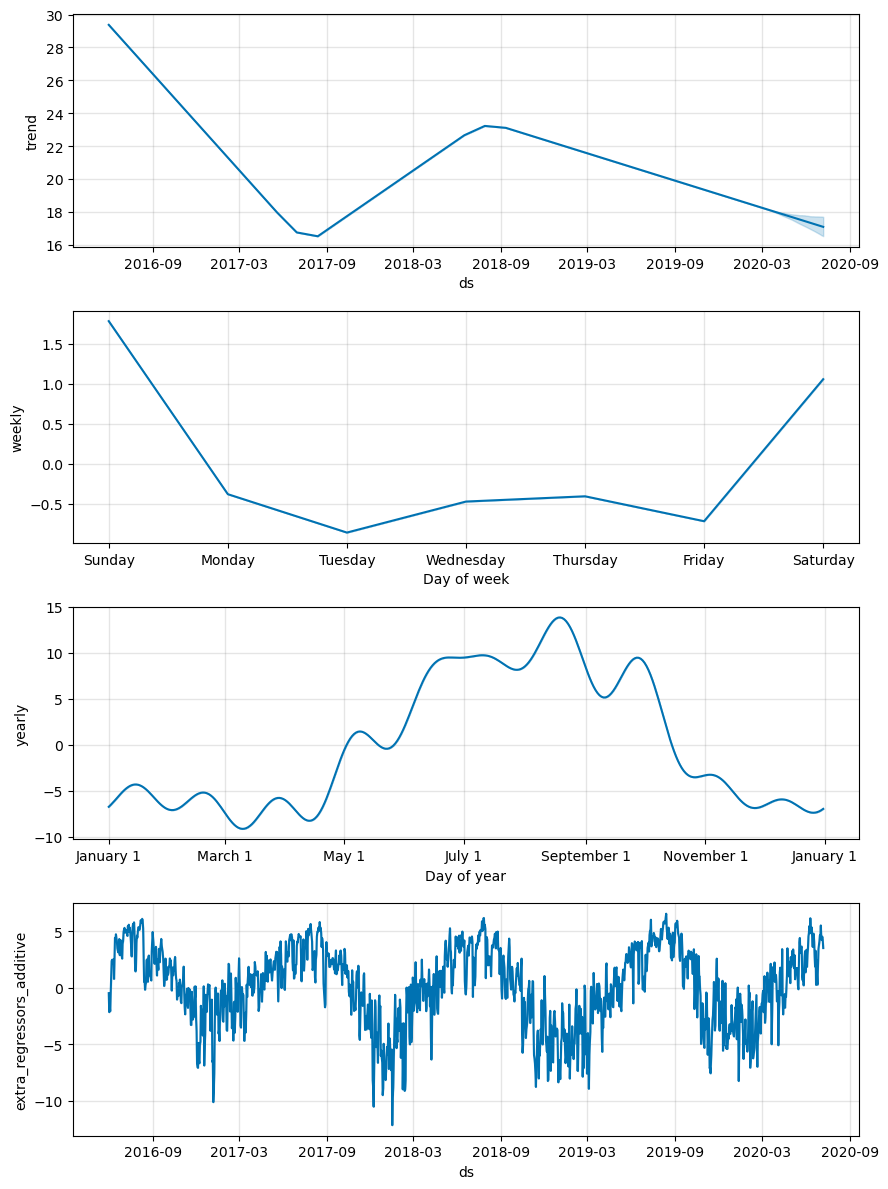


 Paso 3: Calculando el MAE 
Resultados del Modelo Prophet (SIN REGRESORES) - (Paso 1.3):
MAE en Entrenamiento: 4.8205 kWh
MAE en Prueba:        4.9340 kWh

Resultados del Modelo Prophet (CON REGRESORES) - (Paso 1.4):
MAE en Entrenamiento: 4.7542 kWh
MAE en Prueba:        4.5228 kWh


In [ ]:
print("Paso 0: Cargando y Uniendo Datos de Regresores (datos_frink.csv) ")

# Cargar los datos meteorológicos
try:
    df_frink = pd.read_csv('datos_frink.csv', parse_dates=['date'])
except FileNotFoundError:
    print("Error: No se encontró el archivo 'datos_frink.csv'.")
    raise

regressors_list = ['Temp_avg', 'Hum_avg', 'Wind_avg']
print(f"Regresores seleccionados: {regressors_list}")

df_frink_selected = df_frink[['date'] + regressors_list]

df_full_regressors = pd.merge(df, df_frink_selected, on='date', how='left')

if df_full_regressors[regressors_list].isnull().any().any():
    print("Se encontraron NaNs en los regresores. Rellenando con 'forward fill'...")
    df_full_regressors[regressors_list] = df_full_regressors[regressors_list].fillna(method='ffill')
    df_full_regressors[regressors_list] = df_full_regressors[regressors_list].fillna(method='bfill')

df_full_regressors = df_full_regressors.rename(
    columns={'date': 'ds', 'Energy_kWh': 'y'}
)

# 0. Preparar DataFrames para el modelo 

# Definir la fecha de corte 
split_datetime = pd.to_datetime(split_date)

# 1. DataFrame para .fit(): Necesita ds, y + regresores 
prophet_train_reg = df_full_regressors[df_full_regressors['ds'] <= split_datetime].copy()
    
# 2. DataFrame para .predict()
future_reg = df_full_regressors[['ds'] + regressors_list].copy()

print(f"Datos de entrenamiento (con regresores) listos: {prophet_train_reg.shape}")
print(f"Datos futuros (con regresores) listos: {future_reg.shape}")


# 1. Crear, Añadir Regresores y Ajustar Modelo 

print("\n Paso 1: Creando, Añadiendo Regresores y Ajustando Modelo ")

m_reg = Prophet()

# Añadir los regresores 
for regressor in regressors_list:
    print(f"Añadiendo regresor: {regressor}")
    m_reg.add_regressor(regressor)

# Entrenar el modelo
print("Ajustando (fit) el modelo con regresores...")
m_reg.fit(prophet_train_reg)
print("Ajuste completado.")


# 2. Graficar Predicciones y Componentes 

print("\n Paso 2: Graficando Predicciones y Componentes ")

# Generar predicciones
forecast_reg = m_reg.predict(future_reg)

# Gráfico 1: Predicción (Forecast)
print("Generando gráfico de predicción (prophet_forecast_reg.png)...")
fig1_reg = m_reg.plot(forecast_reg)
ax1_reg = fig1_reg.gca()
ax1_reg.axvline(split_datetime, color='grey', linestyle='--', lw=2)
plt.title("Predicción del Modelo Prophet con Regresores")
plt.xlabel("Fecha")
plt.ylabel("Consumo (kWh)")
plt.savefig('prophet_forecast_reg.png')
plt.show() 

# Gráfico 2: Componentes (Components)
print("Generando gráfico de componentes (prophet_components_reg.png)...")
fig2_reg = m_reg.plot_components(forecast_reg)
plt.savefig('prophet_components_reg.png')
plt.show() 


# 3. Calcular el MAE 

print("\n Paso 3: Calculando el MAE ")

# Unir los valores reales (y) con los nuevos predichos (yhat de 'forecast_reg')
comparison_df_reg = pd.merge(df_prophet_full, forecast_reg[['ds', 'yhat']], on='ds')

# Separar en train y test
train_comparison_reg = comparison_df_reg[comparison_df_reg['ds'] <= split_datetime]
test_comparison_reg = comparison_df_reg[comparison_df_reg['ds'] > split_datetime]

# Calcular MAE
mae_train_prophet_reg = mean_absolute_error(train_comparison_reg['y'], train_comparison_reg['yhat'])
mae_test_prophet_reg = mean_absolute_error(test_comparison_reg['y'], test_comparison_reg['yhat'])

print(f"Resultados del Modelo Prophet (SIN REGRESORES) - (Paso 1.3):")
print(f"MAE en Entrenamiento: {mae_train_prophet:.4f} kWh")
print(f"MAE en Prueba:        {mae_test_prophet:.4f} kWh")

print(f"\nResultados del Modelo Prophet (CON REGRESORES) - (Paso 1.4):")
print(f"MAE en Entrenamiento: {mae_train_prophet_reg:.4f} kWh")
print(f"MAE en Prueba:        {mae_test_prophet_reg:.4f} kWh")

La inclusión de regresores exógenos mejora significativamente el rendimiento del modelo, lo cual se confirma al calcular el Error Absoluto Medio (MAE). El modelo Prophet con regresores alcanzó un **MAE en Prueba de 4.5228 kWh**, lo que representa una reducción notable frente al MAE de 4.9340 kWh del modelo Prophet base. Esta disminución del error demuestra cuantitativamente que las variables meteorológicas (`Temp_avg`, `Hum_avg`, `Wind_avg`) poseen un poder explicativo real. El modelo ya no solo se basa en la fecha para predecir el consumo, sino que ahora puede atribuir la variabilidad diaria a factores causales como la temperatura y la humedad, resultando en un ajuste más preciso y robusto.

In [ ]:
print("Calculando y graficando el error (residuales) del modelo final...")

# 1. Calcular el Error 
comparison_df_reg['error'] = comparison_df_reg['y'] - comparison_df_reg['yhat']

# 2. Graficar el Error 
fig_error_reg = px.line(comparison_df_reg, 
                        x='ds', 
                        y='error', 
                        title='Error del Modelo Prophet con Regresores (Residuales)',
                        labels={'ds': 'Fecha', 'error': 'Error (Real - Predicho) kWh'}
                       )

# 3. Añadir líneas de referencia 

fig_error_reg.add_hline(y=0, 
                        line_width=2, 
                        line_dash="dash", 
                        line_color="red"
                       )

fig_error_reg.add_vline(x=split_datetime, 
                        line_width=2, 
                        line_dash="dot", 
                        line_color="grey"
                       )

fig_error_reg.add_annotation(
    x=split_datetime,
    y=comparison_df_reg['error'].max(), 
    text="Separación Train/Test",
    showarrow=True,
    arrowhead=1,
    yshift=10 
)

# 4. Mostrar el gráfico 
fig_error_reg.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Error (kWh)',
    title_x=0.5 
)

fig_error_reg.show()

Calculando y graficando el error (residuales) del modelo final...


**Sí existe un comportamiento estacional** en la serie; de hecho, es su componente más dominante. La evidencia visual de los datos brutos y la modelización explícita realizada por Prophet (vista en el gráfico de componentes) demuestran patrones claros y predecibles tanto anualmente (`yearly`) como semanalmente (`weekly`). Las variables exógenas **sí influyen de manera significativa** en el consumo energético. La prueba cuantitativa es la reducción del Error Absoluto Medio (MAE) en el conjunto de prueba, que **disminuyó de 4.9340 kWh** (en el modelo Prophet base) a **4.5228 kWh** al incorporar los datos de temperatura, humedad y viento. Esta mejora confirma que las variables del clima tienen un poder explicativo real y capturan una parte de la variabilidad que la estacionalidad por sí sola no podía justificar.

## 1.5 Aplicando Lags [7 puntos]

<center>
<img src ="https://i.gifer.com/J45h.gif" width = 400 />

Homero, satisfecho con los resultados obtenidos, cree que aún puede mejorar el rendimiento del modelo incorporando lags de las variables exógenas. Se le ocurre que, al incluir estos lags, podría identificar cómo los valores pasados de las variables influyen en la evolución de la variable objetivo. Con esta idea en mente, Homero solicita su ayuda para encontrar y aplicar los lags adecuados a las variables exógenas de manera efectiva.

Para ello, a usted se le pide que:

1. Calcule la `Autocorrelación Parcial` de las variables exógenas `avg` que usted haya considerado. Por ejemplo: `Temp_avg, Dew_avg, etc`. Luego determine la cantidad de rezagos (lags) que se va a aplicar a cada una de las variables. Justifique. [1 punto]

2. Aplique los lags determinados en el paso anterior e incluyalos como variables en los conjuntos train y test. [1 punto]

3. Impute los valores nulos de los nuevos atributos lags mediante la media de cada variable. [1 punto]

4. Cree y entrene el modelo Prophet e incluya las variables exógenas y adicionalmente sus respectivos lags al modelo. [1 punto]

5. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
6. Calcule el `MAE` de la predicción en el conjunto de prueba y en el de entrenamiento. Analice sus resultados. [1 punto]
7. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y en el de prueba. ¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo? [1 punto]


**Respuesta:**

Paso 1: Calculando PACF para determinar lags 


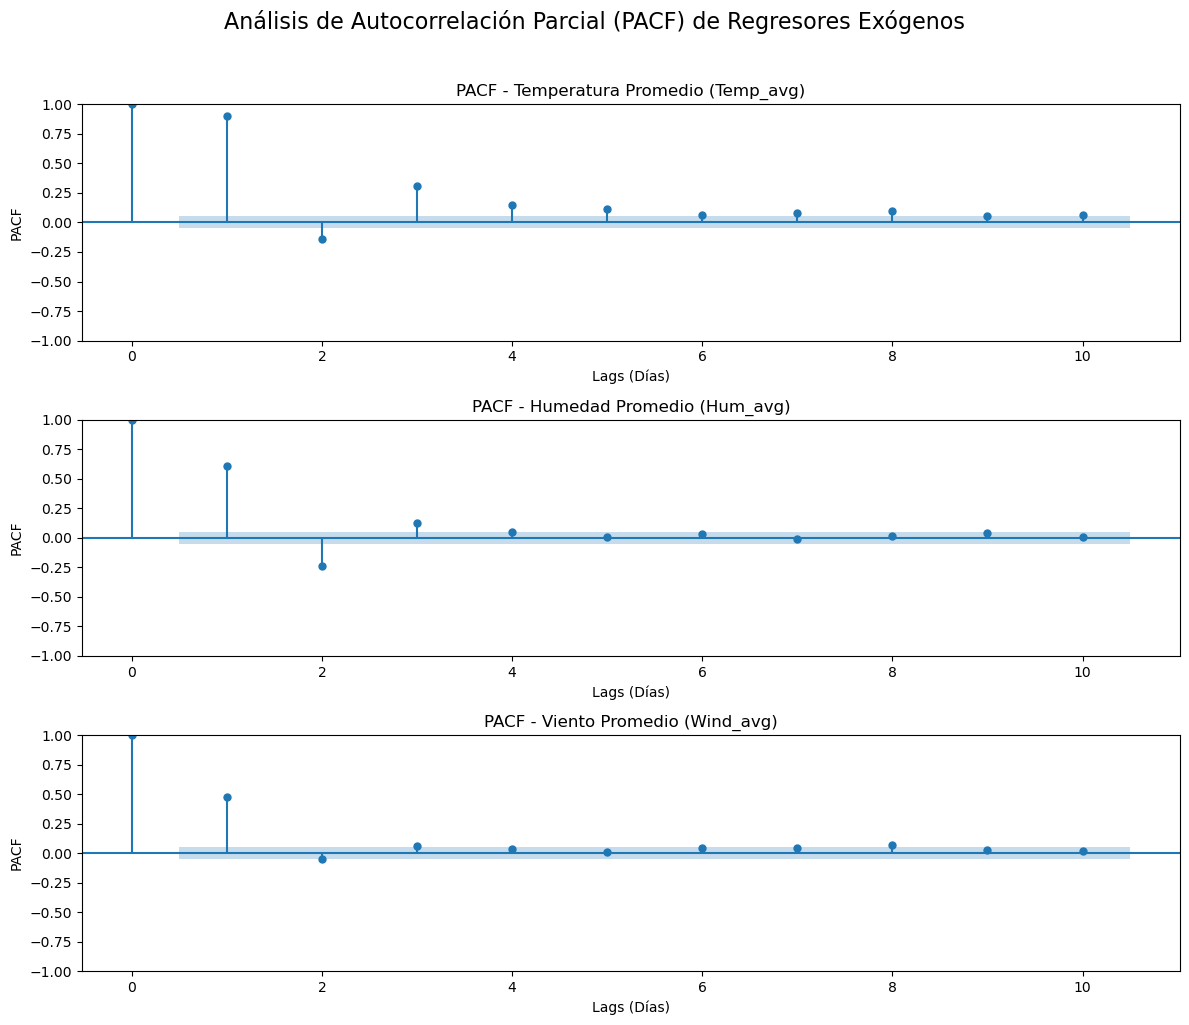

In [ ]:
# 1. Calcular y Graficar la Autocorrelación Parcial (PACF) 

from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

print("Paso 1: Calculando PACF para determinar lags ")

# Configurar un gráfico de 3 filas, 1 columna
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# Título general
fig.suptitle('Análisis de Autocorrelación Parcial (PACF) de Regresores Exógenos', fontsize=16, y=1.02)

# Gráfico 1: Temp_avg
# 'lags=10' para ver los primeros 10 días de rezago
plot_pacf(df_full_regressors['Temp_avg'], lags=10, ax=ax1, method='ywm')
ax1.set_title('PACF - Temperatura Promedio (Temp_avg)')
ax1.set_xlabel('Lags (Días)')
ax1.set_ylabel('PACF')

# Gráfico 2: Hum_avg
plot_pacf(df_full_regressors['Hum_avg'], lags=10, ax=ax2, method='ywm')
ax2.set_title('PACF - Humedad Promedio (Hum_avg)')
ax2.set_xlabel('Lags (Días)')
ax2.set_ylabel('PACF')

# Gráfico 3: Wind_avg
plot_pacf(df_full_regressors['Wind_avg'], lags=10, ax=ax3, method='ywm')
ax3.set_title('PACF - Viento Promedio (Wind_avg)')
ax3.set_xlabel('Lags (Días)')
ax3.set_ylabel('PACF')

# Ajustar layout y mostrar
plt.tight_layout()
plt.savefig('pacf_regressors.png')
plt.show()

Paso 2: Aplicando Lags (k=1) a los regresores 
Nuevos regresores creados: ['Temp_avg_lag1', 'Hum_avg_lag1', 'Wind_avg_lag1']
Imputando NaNs (creados por el shift) usando la media...

 Paso 4: Creando y Entrenando Modelo con Lags 
Total de regresores a usar: 6
Ajustando (fit) el modelo con 6 regresores (originales + lags)...


C:\Users\hayte\AppData\Local\Temp\ipykernel_14476\762775229.py:27: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





Ajuste completado.

 Paso 5: Graficando Predicciones y Componentes (con Lags) 
Generando gráfico de predicción (prophet_forecast_lags.png)...


c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



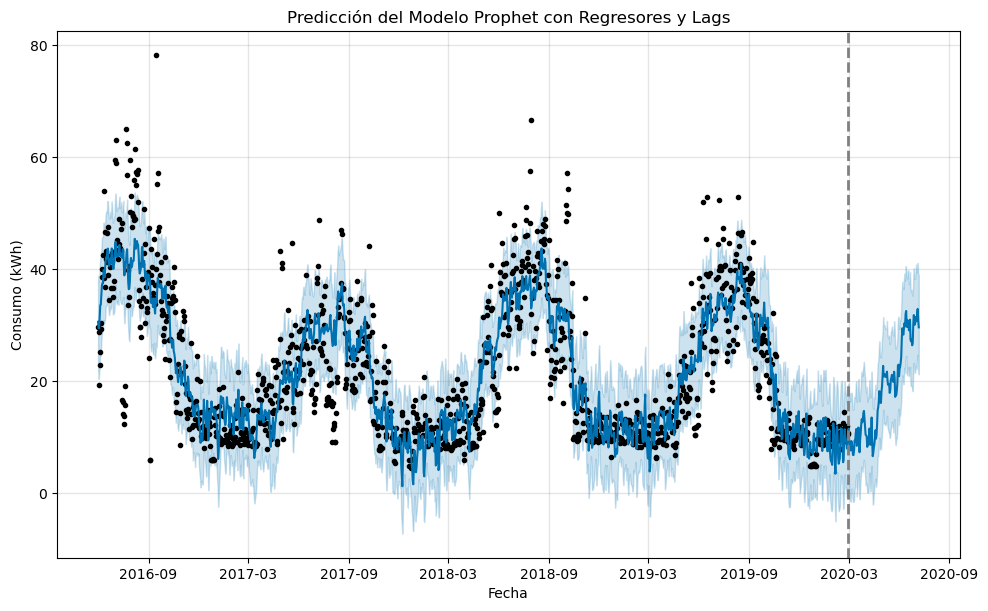

Generando gráfico de componentes (prophet_components_lags.png)...


c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\anaconda3\env

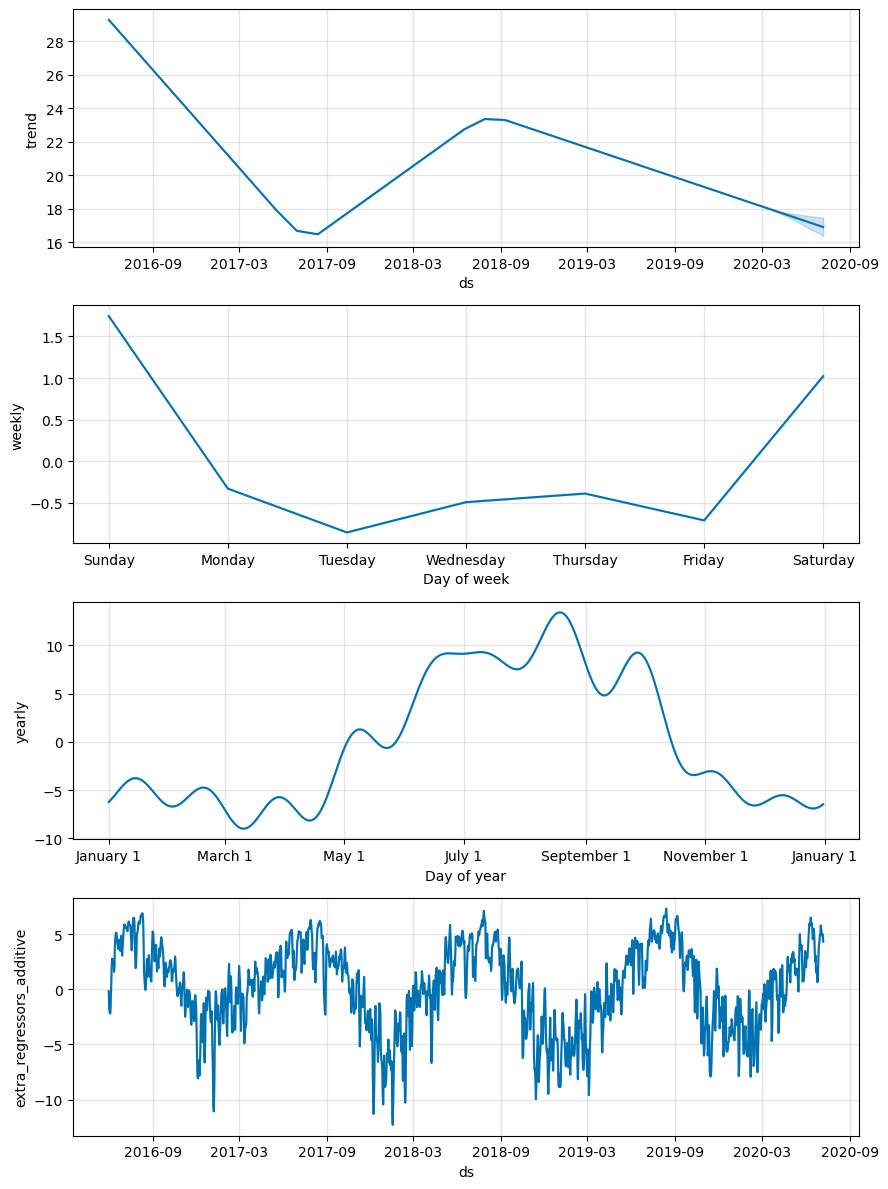


 Paso 6: Calculando el MAE (con Lags)

 Comparación Final de Modelos Prophet (MAE en kWh)

Resultados del Modelo Prophet (SIN REGRESORES) - (Paso 1.3):
MAE en Entrenamiento: 4.8205 kWh
MAE en Prueba:        4.9340 kWh

Resultados del Modelo Prophet (CON REGRESORES) - (Paso 1.4):
MAE en Entrenamiento: 4.7542 kWh
MAE en Prueba:        4.5228 kWh

Resultados del Modelo Prophet (CON REGRESORES + LAGS) - (Paso 1.5):
MAE en Entrenamiento: 4.7285 kWh
MAE en Prueba:        4.5040 kWh


In [ ]:
print("Paso 2: Aplicando Lags (k=1) a los regresores ")

df_lags = df_full_regressors.copy()

# Definir la lista de nuevos regresores 
lag_regressors_list = []
for reg in regressors_list:
    lag_col_name = f"{reg}_lag1"
    
    # (Paso 2) Aplicar el lag de 1 día
    df_lags[lag_col_name] = df_lags[reg].shift(1)
    
    lag_regressors_list.append(lag_col_name)

print(f"Nuevos regresores creados: {lag_regressors_list}")

# Paso 3: Imputando valores nulos con la media

print("Imputando NaNs (creados por el shift) usando la media...")
for col in lag_regressors_list:
    # Calcular la media de la columna 
    mean_val = df_lags[col].mean()
    
    # Rellenar el NaN con la media
    df_lags[col].fillna(mean_val, inplace=True)

# Paso 4: Crear y Entrenar el Modelo Prophet con Lags 

print("\n Paso 4: Creando y Entrenando Modelo con Lags ")

# Lista completa de todos los regresores (3 originales + 3 lags)
all_regressors = regressors_list + lag_regressors_list
print(f"Total de regresores a usar: {len(all_regressors)}")

# Preparar DataFrames para el modelo
# 1. DataFrame para .fit(): ds, y + 6 regresores 
prophet_train_lags = df_lags[df_lags['ds'] <= split_datetime].copy()
    
# 2. DataFrame para .predict(): ds + 6 regresores 
future_lags = df_lags[['ds'] + all_regressors].copy()

# Crear el modelo
m_lags = Prophet()

# Añadir los 6 regresores
for reg in all_regressors:
    m_lags.add_regressor(reg)

# Entrenar el modelo
print("Ajustando (fit) el modelo con 6 regresores (originales + lags)...")
m_lags.fit(prophet_train_lags)
print("Ajuste completado.")

# Paso 5: Graficar Predicciones y Componentes 

print("\n Paso 5: Graficando Predicciones y Componentes (con Lags) ")

# Generar predicciones
forecast_lags = m_lags.predict(future_lags)

# Gráfico 1: Predicción (Forecast)
print("Generando gráfico de predicción (prophet_forecast_lags.png)...")
fig1_lags = m_lags.plot(forecast_lags)
ax1_lags = fig1_lags.gca()
ax1_lags.axvline(split_datetime, color='grey', linestyle='--', lw=2)
plt.title("Predicción del Modelo Prophet con Regresores y Lags")
plt.xlabel("Fecha")
plt.ylabel("Consumo (kWh)")
plt.savefig('prophet_forecast_lags.png')
plt.show() 

# Gráfico 2: Componentes (Components)
print("Generando gráfico de componentes (prophet_components_lags.png)...")
fig2_lags = m_lags.plot_components(forecast_lags)
plt.savefig('prophet_components_lags.png')
plt.show() 

# Paso 6: Calcular el MAE (con Lags) 

print("\n Paso 6: Calculando el MAE (con Lags)")

# Unir los valores reales (y) con los nuevos predichos (yhat de 'forecast_lags')
comparison_df_lags = pd.merge(df_prophet_full, forecast_lags[['ds', 'yhat']], on='ds')

# Separar en train y test
train_comparison_lags = comparison_df_lags[comparison_df_lags['ds'] <= split_datetime]
test_comparison_lags = comparison_df_lags[comparison_df_lags['ds'] > split_datetime]

# Calcular MAE
mae_train_lags = mean_absolute_error(train_comparison_lags['y'], train_comparison_lags['yhat'])
mae_test_lags = mean_absolute_error(test_comparison_lags['y'], test_comparison_lags['yhat'])

print("\n Comparación Final de Modelos Prophet (MAE en kWh)")

print(f"\nResultados del Modelo Prophet (SIN REGRESORES) - (Paso 1.3):")
print(f"MAE en Entrenamiento: {mae_train_prophet:.4f} kWh")
print(f"MAE en Prueba:        {mae_test_prophet:.4f} kWh")

print(f"\nResultados del Modelo Prophet (CON REGRESORES) - (Paso 1.4):")
print(f"MAE en Entrenamiento: {mae_train_prophet_reg:.4f} kWh")
print(f"MAE en Prueba:        {mae_test_prophet_reg:.4f} kWh")

print(f"\nResultados del Modelo Prophet (CON REGRESORES + LAGS) - (Paso 1.5):")
print(f"MAE en Entrenamiento: {mae_train_lags:.4f} kWh")
print(f"MAE en Prueba:        {mae_test_lags:.4f} kWh")

El cálculo del Error Absoluto Medio (MAE) para el modelo, que incluye tanto los regresores exógenos como sus respectivos lags, permite una comparación directa de su rendimiento. El **MAE en Prueba** para este modelo fue de **4.5040 kWh**, mientras que el MAE en Entrenamiento fue de 4.7285 kWh. Al comparar este resultado con el del modelo anterior, se observa una **leve pero positiva mejora** en la precisión. Esto demuestra que la inclusión de los valores del día anterior (lags) sí aporta poder predictivo adicional, aunque de manera marginal. El resultado sugiere el concepto de rendimientos decrecientes, ya que la mayor parte de la variabilidad climática ya había sido capturada por los regresores del día actual.

In [ ]:
print("Paso 7: Graficando el Error Final (Residuales del modelo con Lags)")

# 1. Calcular el Error
comparison_df_lags['error'] = comparison_df_lags['y'] - comparison_df_lags['yhat']

# 2. Graficar el Error
fig_error_lags = px.line(comparison_df_lags,
                         x='ds',
                         y='error',
                         title='Error del Modelo Final (Prophet + Regresores + Lags)',
                         labels={'ds': 'Fecha', 'error': 'Error (Real - Predicho) kWh'}
                        )

# 3. Añadir líneas de referencia

fig_error_lags.add_hline(y=0,
                         line_width=2,
                         line_dash="dash",
                         line_color="red"
                        )

fig_error_lags.add_vline(x=split_datetime,
                         line_width=2,
                         line_dash="dot",
                         line_color="grey"
                        )

fig_error_lags.add_annotation(
    x=split_datetime,
    y=comparison_df_lags['error'].max(), 
    text="Separación Train/Test",
    showarrow=True,
    arrowhead=1,
    yshift=10
)

# 4. Mostrar el gráfico
fig_error_lags.update_layout(
    xaxis_title='Fecha',
    yaxis_title='Error (kWh)',
    title_x=0.5 
)

fig_error_lags.show()

Paso 7: Graficando el Error Final (Residuales del modelo con Lags)


El gráfico de error final, que muestra los residuales del modelo Prophet tras incluir regresores y sus lags, confirma un buen ajuste. La serie de error presenta un comportamiento de **ruido blanco**, con fluctuaciones aleatorias centradas en la línea cero y una ausencia total de los patrones estacionales vistos previamente. Este es el resultado deseado, ya que indica que el modelo final ha capturado de buena manera toda la información estructural y predecible (tendencia, estacionalidad y el efecto de las variables exógenas). El error restante, que promedia un MAE de 4.5040 kWh, representa la variabilidad irreducible y aleatoria inherente al consumo de energía.

## 1.6 Optimizando Prophet [6 puntos]

<center>
<img src ="https://i.gifer.com/BKlg.gif" width = 500 />

Homero, contento con sus resultados, decide compartir su trabajo en LinkedIn. Sin embargo, justo antes de realizar la publicación, su hija Lisa Simpson le comenta que su modelo podría mejorar aún más mediante la optimización de hiperparámetros. Aunque Homero no entiende muy bien a qué se refiere Lisa, decide confiar en su conocimiento y le pide ayuda para implementar la optimización.

Lisa le prepara una función llamada optimize_prophet, que recibe como entrada el registro histórico, los datos a predecir (futuros), el nombre de las variables exógenas y una grilla de hiperparámetros que se desea modificar.

Después de varios intentos, Homero no logra utilizar la función de Lisa y, desesperado por publicar sus resultados en internet, se acerca a usted en busca de ayuda.

Para ello, usted decide realizar los siguientes pasos:

1. Crear una grilla donde se modifiquen los siguientes hiperparámetros: `changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `changepoint_range` y encuentre los hiperparámetros que optimicen el `MAE`. `Nota:` Utilice la función `optimize_prophet()` dada en el enunciado. [1 punto]
2. Crear y entrenar un modelo Prophet utilizando los mejores parámetros encontrados, incluyendo regresores (variables exógenas). [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y en el de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en ambos conjuntos. Analice sus resultados. [1 punto]


In [91]:
#NO MODIFICAR ESTA CELDA

import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
import logging

# Silenciar el logging de Prophet
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)


def optimize_prophet(df, df_to_pred, features, param_grid ):
  '''
  Función que recibe como entrada:
  -df: data entrenamiento.
  -df_to_pred: data a predecir (test).
  -features: lista de variables exógenas.
  -param_grid: grilla de hiperparámetros.

  Retorna:
  -tuning_results: Dataframe con resultados de la optimización.
  -best_params: Diccionario de mejores parámetros encontrados.
  '''

  # Generate all combinations of parameters
  all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
  MAEs = []  # Store the MAEs for each params here

  # Use tqdm to add a progress bar to the parameter tuning loop
  for params in tqdm(all_params, desc="Tuning Prophet parameters"):
      m = Prophet(**params)  # Fit model with given params
      for feature in features:
          m.add_regressor(feature)
      m.fit(df)

      # Prepare future dataframe
      df_prop = m.make_future_dataframe(periods=len(df_to_pred))
      df_feat = pd.concat([df[features], df_to_pred[features]]).reset_index(drop=True)
      df_prop[features] = df_feat[features]

      # Make predictions
      forecast = m.predict(df_prop)
      forecast_pred = forecast[forecast['ds'].isin(df_to_pred['ds'])].reset_index(drop=True)

      # Calculate MAE for the predictions
      mae_pred = mean_absolute_error(df_to_pred['y'], forecast_pred['yhat'])
      MAEs.append(mae_pred)

  # Find the best parameters
  tuning_results = pd.DataFrame(all_params)
  tuning_results['MAEs'] = MAEs
  tuning_results = tuning_results.sort_values(by='MAEs', ascending=True)
  best_params = all_params[np.argmin(MAEs)]
  return tuning_results, best_params

**Respuesta:**

Paso 1: Creando Grilla y Optimizando Hiperparámetros
Grilla de parámetros a probar:
{'changepoint_prior_scale': [0.01, 0.05, 0.1], 'seasonality_prior_scale': [5.0, 10.0, 15.0], 'seasonality_mode': ['additive', 'multiplicative'], 'changepoint_range': [0.8, 0.9]}


Tuning Prophet parameters: 100%|██████████| 36/36 [00:23<00:00,  1.55it/s]



Optimización completada.

 Mejores Hiperparámetros Encontrados
{'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.9}

 Paso 2: Entrenando modelo optimizado
Ajustando (fit) el modelo optimizado...
Ajuste completado.

 Paso 3: Graficando predicciones optimizadas
Generando gráfico de predicción (prophet_forecast_best.png)...


c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



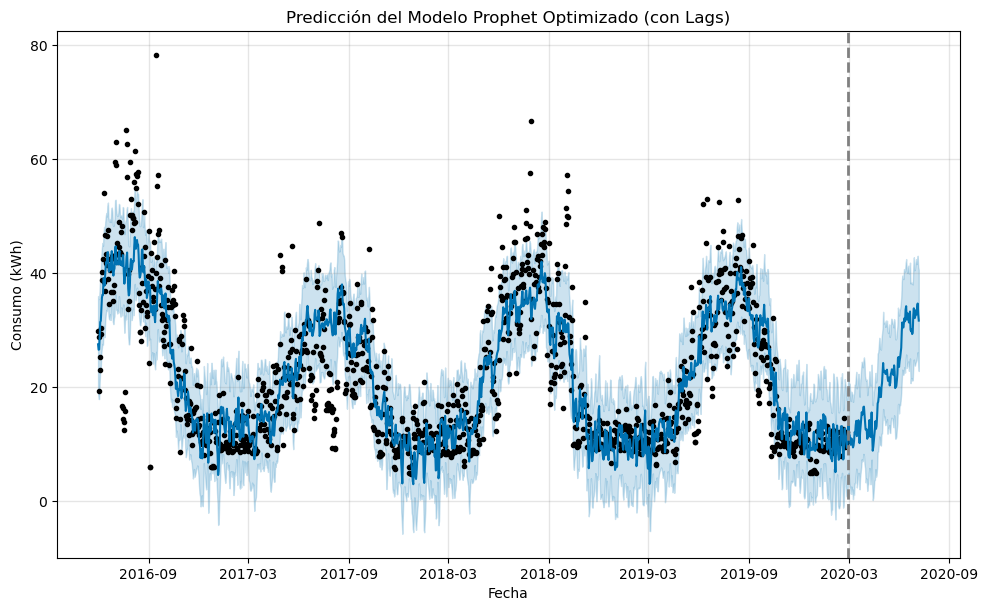

Generando gráfico de componentes (prophet_components_best.png)...


c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\anaconda3\envs\prophet_lab\lib\site-packages\prophet\plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\anaconda3\env

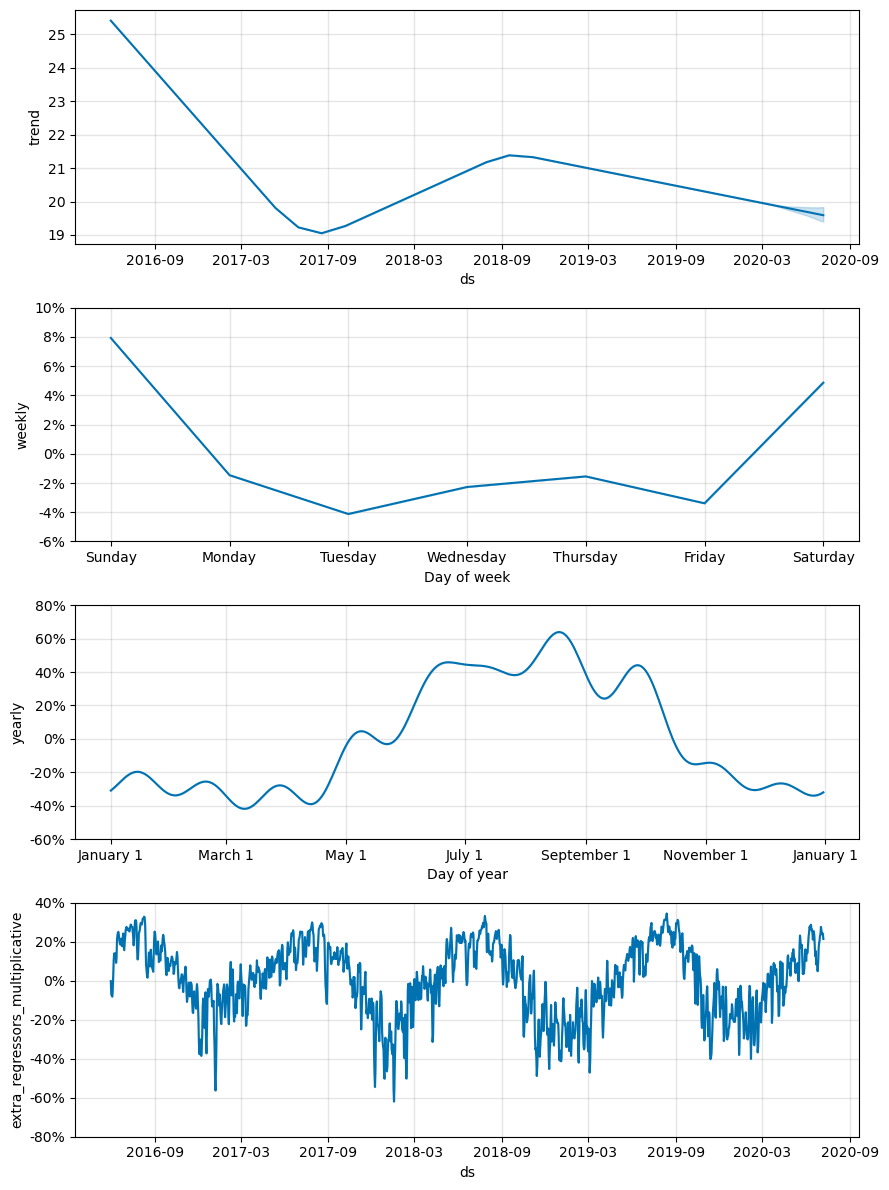


 Paso 4: Calculando MAE optimizado

 Comparación Final de Modelos Prophet (MAE en kWh)
Prophet Base (1.3) 		| Train: 4.8205 	| Test: 4.9340
Prophet + Regs (1.4) 		| Train: 4.7542 	| Test: 4.5228
Prophet + Regs + Lags (1.5) 	| Train: 4.7285 	| Test: 4.5040
Prophet + Regs + Lags + Tuned (1.6) 	| Train: 4.8244 	| Test: 3.9501

 Paso 5: Graficando error optimizado


In [ ]:
print("Paso 1: Creando Grilla y Optimizando Hiperparámetros")

# 1. Crear la Grilla de Hiperparámetros
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1], # Flexibilidad de la tendencia
    'seasonality_prior_scale': [5.0, 10.0, 15.0], # Flexibilidad de la estacionalidad
    'seasonality_mode': ['additive', 'multiplicative'], # Modo de estacionalidad
    'changepoint_range': [0.8, 0.9] # Rango para puntos de cambio de tendencia
}
# Total de combinaciones: 3 * 3 * 2 * 2 = 36 modelos a probar.

print("Grilla de parámetros a probar:")
print(param_grid)

# 1. Preparar datos para la función

# 1. Lista de features (los 6 regresores)
features_list_opt = all_regressors

# 2. Datos de entrenamiento 
train_data_opt = prophet_train_lags

# 3. Datos de prueba 
test_data_opt = df_lags[df_lags['ds'] > split_datetime].copy()

# 1. Ejecutar la Optimización
tuning_results, best_params = optimize_prophet(
    df=train_data_opt,
    df_to_pred=test_data_opt,
    features=features_list_opt,
    param_grid=param_grid
)

print("\nOptimización completada.")
print("\n Mejores Hiperparámetros Encontrados")
print(best_params)


# Paso 2: Crear y Entrenar el Modelo con Parámetros Óptimos

print("\n Paso 2: Entrenando modelo optimizado")

# Crear el modelo usando los mejores parámetros
m_best = Prophet(**best_params)

# Añadir los 6 regresores
for reg in all_regressors:
    m_best.add_regressor(reg)

# Entrenar el modelo
print("Ajustando (fit) el modelo optimizado...")
m_best.fit(prophet_train_lags)
print("Ajuste completado.")


# Paso 3: Graficar Predicciones y Componentes (Optimizados)

print("\n Paso 3: Graficando predicciones optimizadas")

# Generar predicciones 
forecast_best = m_best.predict(future_lags)

# Gráfico 1: Predicción (Forecast)
print("Generando gráfico de predicción (prophet_forecast_best.png)...")
fig1_best = m_best.plot(forecast_best)
ax1_best = fig1_best.gca()
ax1_best.axvline(split_datetime, color='grey', linestyle='--', lw=2)
plt.title("Predicción del Modelo Prophet Optimizado (con Lags)")
plt.xlabel("Fecha")
plt.ylabel("Consumo (kWh)")
plt.savefig('prophet_forecast_best.png')
plt.show()

# Gráfico 2: Componentes (Components)
print("Generando gráfico de componentes (prophet_components_best.png)...")
fig2_best = m_best.plot_components(forecast_best)
plt.savefig('prophet_components_best.png')
plt.show()

# Paso 4: Calcular el MAE (Optimizado)

print("\n Paso 4: Calculando MAE optimizado")

# Unir reales (y) con los nuevos predichos (yhat)
comparison_df_best = pd.merge(df_prophet_full, forecast_best[['ds', 'yhat']], on='ds')

# Separar train y test
train_comparison_best = comparison_df_best[comparison_df_best['ds'] <= split_datetime]
test_comparison_best = comparison_df_best[comparison_df_best['ds'] > split_datetime]

# Calcular MAE
mae_train_best = mean_absolute_error(train_comparison_best['y'], train_comparison_best['yhat'])
mae_test_best = mean_absolute_error(test_comparison_best['y'], test_comparison_best['yhat'])

print("\n Comparación Final de Modelos Prophet (MAE en kWh)")
print(f"Prophet Base (1.3) \t\t| Train: {mae_train_prophet:.4f} \t| Test: {mae_test_prophet:.4f}")
print(f"Prophet + Regs (1.4) \t\t| Train: {mae_train_prophet_reg:.4f} \t| Test: {mae_test_prophet_reg:.4f}")
print(f"Prophet + Regs + Lags (1.5) \t| Train: {mae_train_lags:.4f} \t| Test: {mae_test_lags:.4f}")
print(f"Prophet + Regs + Lags + Tuned (1.6) \t| Train: {mae_train_best:.4f} \t| Test: {mae_test_best:.4f}")


# Paso 5: Graficar el Error (Residuales Optimizados)

print("\n Paso 5: Graficando error optimizado")

# Calcular el error
comparison_df_best['error'] = comparison_df_best['y'] - comparison_df_best['yhat']

# Graficar el error
fig_error_best = px.line(comparison_df_best,
                         x='ds',
                         y='error',
                         title='Error del Modelo Final Optimizado (Prophet + Regs + Lags + Tuned)',
                         labels={'ds': 'Fecha', 'error': 'Error (Real - Predicho) kWh'}
                        )

# Añadir líneas de referencia
fig_error_best.add_hline(y=0, line_width=2, line_dash="dash", line_color="red")
fig_error_best.add_vline(x=split_datetime, line_width=2, line_dash="dot", line_color="grey")
fig_error_best.add_annotation(
    x=split_datetime,
    y=comparison_df_best['error'].max(),
    text="Separación Train/Test",
    showarrow=True, arrowhead=1, yshift=10
)

# Mostrar el gráfico
fig_error_best.update_layout(xaxis_title='Fecha', yaxis_title='Error (kWh)', title_x=0.5)
fig_error_best.show()

El modelo optimizado alcanzó un **Error Absoluto Medio (MAE) en Prueba de 3.9501 kWh**, una mejora sustancial sobre el 4.5040 kWh del modelo anterior. Este salto en la precisión se debe a la identificación de hiperparámetros óptimos, en particular el cambio a `seasonality_mode='multiplicative'`, lo que permite que el modelo trate la estacionalidad como un factor porcentual (ej. +80% en invierno) en lugar de una suma fija. El gráfico de error residual confirma este ajuste superior: presenta un comportamiento de **ruido blanco**, indicando que toda la información estructural ha sido extraída, y que el MAE restante de 3.95 kWh representa el error aleatorio e irreducible del sistema.

# **2. Sistemas de Recomendación (30 puntos)**

## Homero contra la Prohibición

<center>
<img src ="https://i.ytimg.com/vi/rMSXXuhZjYY/maxresdefault.jpg" width = 500 />

En Springfield, el caos estalló cuando las autoridades prohibieron el alcohol. Pero como siempre, donde otros ven problemas, Homero Simpson ve oportunidades. Decidido a mantener las fiestas vivas, se convirtió en el Barón de la Cerveza en un abrir y cerrar de ojos. Con la ayuda de su buen amigo Moe el cantinero, Homero obtuvo un valioso dataset llamado `cervezas.csv`, que contiene valoraciones de los ciudadanos de Springfield sobre distintas cervezas. Homero quiere asegurarse de ofrecer las cervezas más apreciadas para mantener a su clientela oculta y feliz, mientras eludía la mirada del estricto Elio Pez. Por ende, Homero lo contacta para solicitar de su ayuda en esta nueva labor.

El dataset contiene los siguientes atributos:

  * userId: Identificador de los ciudadanos/usuarios
  * beerId: Identificador único de cada cerveza
  * rating: Evaluación otorgada por el ciudadano a la cerveza, en un rango de 1.0 a 5.0.
  * beerName: Nombre de la cerveza
  * beerStyle: Tipo de Cerveza.



In [93]:
# Librerias extras
from sklearn.preprocessing import LabelEncoder

from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.prediction_algorithms.knns import KNNBasic
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise.accuracy import mae
from surprise import NMF
from collections import defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pandas as pd
from copy import deepcopy

## Carga de los datos [0 puntos]

Cargue el dataset `cervezas.csv` y realice una breve exploración de los datos. ¿Hay valores nulos? ¿Cuantos cervezas se estan evaluando? ¿Cuantos ciudadanos participaron de esta evaluación?

In [ ]:
# 0. Carga de los datos
print("Cargando 'cervezas.csv'...")

try:
    df_beers = pd.read_csv('cervezas.csv')
except FileNotFoundError:
    print("Error: No se encontró el archivo 'cervezas.csv'.")
    df_beers = pd.DataFrame(columns=['userId', 'beerId', 'rating', 'beerName', 'beerStyle'])

if not df_beers.empty:
    print("Datos cargados exitosamente.")
    print("\n Exploración Inicial")
    print("Primeras 5 filas del dataset:")
    print(df_beers.head())
    
    print("\nInformación general y tipos de datos:")
    df_beers.info()
    print("\n Análisis del Dataset")

    # 1. ¿Hay valores nulos?
    print("\n1. Conteo de valores nulos por columna:")
    null_counts = df_beers.isnull().sum()
    print(null_counts)
    
    if null_counts.sum() == 0:
        print("-> Análisis de Nulos: No se encontraron valores nulos.")
    else:
        print(f"-> Análisis de Nulos: Sí, hay un total de {null_counts.sum()} valores nulos.")

    # 2. ¿Cuantas cervezas se estan evaluando?
    # beerId por ser un identificador único.
    num_unique_beers = df_beers['beerId'].nunique()
    print(f"\n2. Número de cervezas únicas evaluadas (por beerId): {num_unique_beers}")

    # 3. ¿Cuantos ciudadanos participaron de esta evaluación?
    num_unique_users = df_beers['userId'].nunique()
    print(f"\n3. Número de ciudadanos (usuarios) únicos: {num_unique_users}")

else:
    print("\nEl DataFrame está vacío. No se puede continuar con el análisis.")

Cargando 'cervezas.csv'...
Datos cargados exitosamente.

 Exploración Inicial
Primeras 5 filas del dataset:
   userId  beerId  rating                            beerName  \
0     144     995     3.0                            Mai Bock   
1      63   58695     4.0  Hop In The Dark Cascadian Dark Ale   
2     147    4083     5.0                 Stone Ruination IPA   
3    4261   40310     3.0                     Noël Des Géants   
4     140    1904     5.0       Sierra Nevada Celebration Ale   

                        beerStyle  
0           Maibock / Helles Bock  
1              American Black Ale  
2  American Double / Imperial IPA  
3            Herbed / Spiced Beer  
4                    American IPA  

Información general y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295059 entries, 0 to 295058
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     295059 non-null  int64  
 1   beerId  

### Valores nulos

No hay valores nulos, el dataset está completo.


### ¿Cuántas cervezas se están evaluando?
Hay 3747 cervezas únicas.

### ¿Cuántos ciudadanos participaron de esta evaluación?
Hay 706 ciudadanos únicos.

## 2.1 Caracterización Inicial [3 puntos]

Antes de entrenar nuestro sistema recomendador, es necesario caracterizar los datos disponibles y de esta manera tener un mejor entendimiento del problema a resolver. Para esto, se le pide lo siguiente:

1. Genere gráficos y/o estadística descriptiva con los datos. Utilice su análisis para responder las siguientes preguntas: [2 puntos]
  - ¿Cuantos *usuarios* hay en los datos?
  - ¿Cuantos *productos* hay en los datos?
  - ¿Cuantas *calificaciones* hay en los datos?
  - ¿Cuantas *calificaciones* faltantes hay en los datos?
  - ¿Cual es la media de las *calificaciones* entregadas por los usuarios? ¿Cómo cambia esto a través de los productos?  
2. Transforme los datos entregados a una matriz (usuario, producto) y muestre sus resultados. [1 punto]

In [ ]:
print("1. Caracterización de Calificaciones (Ratings)")

# Gráfico 1: Distribución de Calificaciones
rating_counts = df_beers['rating'].value_counts().sort_index().reset_index()
rating_counts.columns = ['Rating', 'Count']

rating_counts['Rating'] = rating_counts['Rating'].astype(str)

fig_rating_dist = px.bar(rating_counts, 
                         x='Rating', 
                         y='Count', 
                         title='Distribución de Calificaciones Otorgadas (1.0 a 5.0)',
                         labels={'Rating': 'Calificación', 'Count': 'Número de Votos'},
                         text_auto=True) 
fig_rating_dist.update_layout(title_x=0.5)
fig_rating_dist.show()

# 2. Análisis de Calificaciones Faltantes (Sparsity)
print("\n 2. Análisis de Calificaciones Faltantes (Sparsity)")

num_users = df_beers['userId'].nunique()
num_beers = df_beers['beerId'].nunique()
num_ratings = len(df_beers)

# Calcular la matriz total
total_possible_ratings = num_users * num_beers

# Calcular densidad y sparsity
density = num_ratings / total_possible_ratings
sparsity = 1 - density

print(f"Número de usuarios (ciudadanos): {num_users}")
print(f"Número de cervezas (productos): {num_beers}")
print(f"Número de calificaciones (ratings): {num_ratings}")
print(f"Total de calificaciones posibles (matriz N x M): {total_possible_ratings}")
print(f"Densidad de la matriz (Density): {density * 100:.4f}%")
print(f"Sparsity de la matriz (Sparsity): {sparsity * 100:.4f}%")


# 3. Caracterización de Usuarios 
print("\n 3. Caracterización de Usuarios (Ciudadanos)")

# Gráfico 2: Distribución de Actividad de Usuarios (Ratings por Usuario)
user_activity = df_beers.groupby('userId')['rating'].count().reset_index()
user_activity.columns = ['userId', 'RatingsCount']

fig_user_activity = px.histogram(user_activity, 
                                 x='RatingsCount', 
                                 title='Distribución de Actividad de Usuarios (Ratings por Usuario)',
                                 labels={'RatingsCount': 'Número de Ratings Dados', 'count': 'Número de Usuarios'},
                                 nbins=50) 
fig_user_activity.update_layout(title_x=0.5)
fig_user_activity.show()

# Gráfico 3: Distribución de Calificaciones Medias por Usuario
user_mean_rating = df_beers.groupby('userId')['rating'].mean().reset_index()
user_mean_rating.columns = ['userId', 'MeanRating']

fig_user_mean = px.histogram(user_mean_rating, 
                             x='MeanRating', 
                             title='Distribución de Calificaciones Medias por Usuario',
                             labels={'MeanRating': 'Calificación Promedio', 'count': 'Número de Usuarios'},
                             nbins=50)
fig_user_mean.update_layout(title_x=0.5)
fig_user_mean.show()


# 4. Caracterización de Productos
print("\n 4. Caracterización de Productos (Cervezas)")

# Gráfico 4: Distribución de Popularidad de Cervezas (Ratings por Cerveza) 
beer_popularity = df_beers.groupby('beerId')['rating'].count().reset_index()
beer_popularity.columns = ['beerId', 'RatingsCount']

fig_beer_pop = px.histogram(beer_popularity, 
                            x='RatingsCount', 
                            title='Distribución de Popularidad de Cervezas (Ratings por Cerveza)',
                            labels={'RatingsCount': 'Número de Ratings Recibidos', 'count': 'Número de Cervezas'},
                            nbins=50)
fig_beer_pop.update_layout(title_x=0.5)
fig_beer_pop.show()

# Gráfico 5: Distribución de Calificaciones Medias por Cerveza 
beer_mean_rating = df_beers.groupby('beerId')['rating'].mean().reset_index()
beer_mean_rating.columns = ['beerId', 'MeanRating']

fig_beer_mean = px.histogram(beer_mean_rating, 
                             x='MeanRating', 
                             title='Distribución de Calificaciones Medias por Cerveza',
                             labels={'MeanRating': 'Calificación Promedio', 'count': 'Número de Cervezas'},
                             nbins=50)
fig_beer_mean.update_layout(title_x=0.5)
fig_beer_mean.show()

1. Caracterización de Calificaciones (Ratings)



 2. Análisis de Calificaciones Faltantes (Sparsity)
Número de usuarios (ciudadanos): 706
Número de cervezas (productos): 3747
Número de calificaciones (ratings): 295059
Total de calificaciones posibles (matriz N x M): 2645382
Densidad de la matriz (Density): 11.1537%
Sparsity de la matriz (Sparsity): 88.8463%

 3. Caracterización de Usuarios (Ciudadanos)



 4. Caracterización de Productos (Cervezas)


### Respuestas
El análisis exploratorio del conjunto de datos revela la participación de 706 *usuarios* (ciudadanos) que han evaluado un total de 3,747 *productos* (cervezas). En total, se registraron 295,059 *calificaciones*. Dada la matriz de interacciones posibles (usuarios x productos), esto indica que la gran mayoría de las *calificaciones* están faltantes; específicamente, 2,350,323 de entradas están vacías, lo que resulta en una *sparsity* de la matriz del 88.85%. En cuanto a la distribución de las valoraciones, se observa un claro sesgo positivo, siendo 4.0 la calificación individual más frecuente. Al analizar la media de las *calificaciones* entregadas por los usuarios, esta tiende a agruparse en el rango de 3.8 a 4.0. Este comportamiento se refleja de manera casi idéntica en los productos, donde la calificación media recibida por las cervezas también se concentra fuertemente en el mismo rango de 3.8 a 4.0, como lo confirman sus respectivos histogramas.

In [ ]:
print("2. Transformando a Matriz Usuario-Producto (Utility Matrix)")

# pivot_table para crear la matriz
utility_matrix = df_beers.pivot_table(
    index='userId', 
    columns='beerId', 
    values='rating'
)

print(f"Forma de la matriz (Usuarios x Cervezas): {utility_matrix.shape}")
print("\nMostrando las primeras 5 filas de la Utility Matrix (llena de 'NaN' donde no hay calificación):")

print(utility_matrix.head())

2. Transformando a Matriz Usuario-Producto (Utility Matrix)
Forma de la matriz (Usuarios x Cervezas): (706, 3747)

Mostrando las primeras 5 filas de la Utility Matrix (llena de 'NaN' donde no hay calificación):
beerId  5         6         7         9         10        11        14     \
userId                                                                      
1         NaN       NaN       NaN       NaN       NaN       NaN       NaN   
3       3.395  3.765217  3.256849  3.478261       NaN       NaN       NaN   
4         NaN       NaN       NaN       NaN  3.791908       NaN       NaN   
5         NaN       NaN       NaN       NaN       NaN  3.431818       NaN   
6         NaN       NaN       NaN       NaN       NaN       NaN  3.892157   

beerId  15     17     19     ...  74491  74530  74548  74579  74634  74827  \
userId                       ...                                             
1         NaN    NaN    NaN  ...    NaN    NaN    NaN    NaN    NaN    NaN   
3         NaN  

## 2.2 Método Basado en Contenido [4 puntos]

<center>
<img src ="https://is1-ssl.mzstatic.com/image/thumb/WfNa_TwFpJoTWXQmU-BrbA/1200x675.jpg" width = 500 />

Como primera tarea, Homero le pide centrarse en las características de las cervezas y no en la interacción de los ciudadanos con esta. Adicionalmente, Homero le quiere regalar un pack de distintas cervezas a Carl en agradecimiento a su ayuda anterior, el cual se enteró que Carl tiene un `userId = 100`. Por ende, Homero le pide las siguientes acciones:

1. Cree un dataframe que contenga las características de las cervezas, excluyendo las evaluaciones de los ciudadanos. `Nota:` No considere valores duplicados. [1 punto]
2. Implemente el método Bag of Words para procesar la columna `beerStyle`. Para ello, transforme las palabras a minúsculas, elimine stopwords en inglés y filtre las palabras que aparezcan en 10 documentos como mínimo. Guarde su resultado como un DataFrame. [1 punto].
> `Nota:` Le puede ser útil esta [documentacion](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) y el método `.get_feature_names_out()`.
3. Cree una función que imprima las top 5 cervezas similares a `Chocolate Porter`, utilizando como medida de similitud la similitud coseno. [1 punto]
4. Identifique la cerveza mejor evaluada por Carl (`userId = 100`) y obtenga las top 5 cervezas similares a esa cerveza. [1 punto]

**Respuesta:**

In [ ]:
# Paso 1: Crear DataFrame de Características de Cervezas

print("Paso 1: Creando DataFrame de características de cervezas")

df_beers_features = df_beers[['beerId', 'beerName', 'beerStyle']].drop_duplicates(subset=['beerId']).reset_index(drop=True)

print(f"DataFrame de características creado con {len(df_beers_features)} cervezas únicas.")
print("Primeras 5 filas del catálogo de cervezas:")
print(df_beers_features.head())


# Paso 2: Implementar Bag of Words (BoW) en 'beerStyle'

print("\n Paso 2: Implementando Bag of Words (BoW) en 'beerStyle'")

vectorizer = CountVectorizer(
    lowercase=True,         
    stop_words='english',   
    min_df=10               
)

bow_matrix = vectorizer.fit_transform(df_beers_features['beerStyle'])

bow_feature_names = vectorizer.get_feature_names_out()

df_bow = pd.DataFrame(bow_matrix.toarray(), columns=bow_feature_names)

print(f"Matriz BoW creada con forma (Cervezas x Palabras): {df_bow.shape}")
print("Primeras 5 filas del DataFrame BoW:")
print(df_bow.head())


# Paso 3: Función de Similitud Coseno

print("\n Paso 3: Creando función de similitud y recomendando para 'Chocolate Porter'")

# 1. matriz de similitud coseno (NxN) sobre la matriz BoW
print("Calculando matriz de similitud coseno...")
cosine_sim_matrix = cosine_similarity(df_bow)
print(f"Matriz de similitud creada con forma (Cervezas x Cervezas): {cosine_sim_matrix.shape}")

# 2. mapeo (Serie de pandas) del nombre de la cerveza a su índice en la matriz
indices = pd.Series(df_beers_features.index, index=df_beers_features['beerName'])

def get_top5_similar(beer_name, cosine_sim, beer_features, indices_map):
    """
    Imprime las top 5 cervezas más similares a una cerveza dada
    basado en la matriz de similitud coseno pre-calculada.
    """
    print(f"\n Recomendaciones de estilo similar para: '{beer_name}'")
    
    if beer_name not in indices_map:
        print(f"Error: La cerveza '{beer_name}' no se encuentra en el catálogo.")
        return
    
    # 1. Obtener el índice de la cerveza (ej. 'Chocolate Porter' -> índice 1500)
    
    # Manejo de duplicados:
    idx_lookup = indices_map[beer_name]
    
    if isinstance(idx_lookup, pd.Series):
        idx = idx_lookup.iloc[0]
        print(f"Nota: Se encontraron múltiples cervezas con el nombre '{beer_name}'. Usando la primera (índice {idx}).")
    else:
        idx = idx_lookup
             
    # 2. Obtener los puntajes de similitud de esa cerveza con todas las demás
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # 3. Ordenar las cervezas por similitud (de mayor a menor)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # 4. Obtener los puntajes de las 5 cervezas más similares
    sim_scores = sim_scores[1:6]
    
    # 5. Obtener los índices de esas 5 cervezas
    beer_indices = [i[0] for i in sim_scores]
    
    # 6. Mostrar los nombres de las cervezas recomendadas
    print("Top 5 cervezas más similares (basadas en 'beerStyle'):")
    for i, beer_idx in enumerate(beer_indices):
        sim_score = sim_scores[i][1]
        recommended_beer_name = beer_features.iloc[beer_idx]['beerName']
        recommended_beer_style = beer_features.iloc[beer_idx]['beerStyle']
        print(f"  {i+1}. {recommended_beer_name} (Estilo: {recommended_beer_style}) (Similitud: {sim_score:.4f})")

# 3. Ejecutar la función para "Chocolate Porter"
target_beer_name_1 = "Chocolate Porter"
get_top5_similar(target_beer_name_1, cosine_sim_matrix, df_beers_features, indices)


# Paso 4: Recomendaciones para Carl (userId = 100) 

print("\n Paso 4: Recomendaciones para Carl (userId = 100)")

carls_userid = 100

# 1. Filtrar el DataFrame original por las calificaciones de Carl
carls_ratings = df_beers[df_beers['userId'] == carls_userid]

if carls_ratings.empty:
    print(f"Error: El usuario {carls_userid} (Carl) no tiene calificaciones en el dataset.")
else:
    # 2. Ordenar sus calificaciones de mayor a menor y tomar la primera
    carls_top_beer = carls_ratings.sort_values(by='rating', ascending=False).iloc[0]
    
    carls_fav_beer_name = carls_top_beer['beerName']
    carls_fav_beer_rating = carls_top_beer['rating']
    
    print(f"La cerveza mejor evaluada por Carl (userId {carls_userid}) es:")
    print(f"-> '{carls_fav_beer_name}' (le dio un {carls_fav_beer_rating})")
    
    # 3. Obtener recomendaciones basadas en la cerveza favorita de Carl
    get_top5_similar(carls_fav_beer_name, cosine_sim_matrix, df_beers_features, indices)

Paso 1: Creando DataFrame de características de cervezas
DataFrame de características creado con 3747 cervezas únicas.
Primeras 5 filas del catálogo de cervezas:
   beerId                            beerName                       beerStyle
0     995                            Mai Bock           Maibock / Helles Bock
1   58695  Hop In The Dark Cascadian Dark Ale              American Black Ale
2    4083                 Stone Ruination IPA  American Double / Imperial IPA
3   40310                     Noël Des Géants            Herbed / Spiced Beer
4    1904       Sierra Nevada Celebration Ale                    American IPA

 Paso 2: Implementando Bag of Words (BoW) en 'beerStyle'
Matriz BoW creada con forma (Cervezas x Palabras): (3747, 95)
Primeras 5 filas del DataFrame BoW:
   adjunct  ale  altbier  amber  american  apa  baltic  barleywine  beer  \
0        0    0        0      0         0    0       0           0     0   
1        0    1        0      0         1    0       0        

Al implementar el sistema de recomendación basado en contenido, se utilizó un enfoque de "Bag of Words" (BoW) aplicado exclusivamente a la columna `beerStyle`. Tras vectorizar esta característica, se empleó la similitud coseno para encontrar las cervezas más parecidas. Los resultados, tanto para la consulta de "Chocolate Porter" como para la cerveza favorita de Carl (`userId` 100), revelaron que todas las recomendaciones principales tenían un puntaje de similitud perfecto de 1.0. Esto indica que el modelo funciona para agrupar cervezas que comparten la misma etiqueta de estilo exacta, ya que sus vectores de características son idénticos.

## 2.3 Filtros Colaborativos [16 puntos]

<center>
<img src ="https://i.makeagif.com/media/2-08-2016/McmGFQ.gif" width = 400 />

Después de consolidarse como el Barón de la Cerveza en Springfield, Homero Simpson decidió llevar su negocio clandestino a otro nivel. Al ser el único proveedor de alcohol en la ciudad, quiere asegurarse de que cada cerveza que elabora sea de la mejor calidad posible. Para lograrlo, planea usar las evaluaciones pasadas que los ciudadanos de Springfield han registrado sobre las distintas cervezas. Inspirado por los consejos de su amigo Moe, Homero se enteró de que puede implementar un sistema de recomendación basado en filtros colaborativos.

Ahora, Homero necesita de su ayuda para diseñar y elaborar distintos sistemas de filtros colaborativos que le permitan continuar con su reinado cervecero.

### 2.3.1 Filtros Colaborativos Basados en Memoria [8 puntos]

Para este tipo de filtros, Homero le pide lo siguiente:

1. Transforme el DataFrame de `pandas` a Dataset de `surprise`. `Hint`: Utilice solamente los identificadores de ciudadano, cerveza y rating. ¿Importa el orden? [1 punto]
2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba. No olvide fijar una semilla para garantizar reproducibilidad. [1 punto]
3. Entrene un modelo de **KNN basado en usuarios** utilizando la `similitud coseno`. Luego realice predicciones en el conjunto de prueba. `Nota`: Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/knn_inspired.html) [2 puntos]
4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y muestre las predicciones en un DataFrame para su análisis. `Nota:` Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/accuracy.html#surprise.accuracy.mae) [2 puntos]
5. Repita los pasos 3 y 4 pero utilizando un modelo de **KNN basado en los productos**. [2 puntos]

**Respuesta:** Sí, el orden importa, ya que surprise espera las columnas en el orden: userID, itemID, rating.

In [ ]:
from surprise import Reader, Dataset, accuracy
from surprise.model_selection import train_test_split
from surprise.prediction_algorithms.knns import KNNBasic

# Paso 1: Transformar DataFrame a Dataset de Surprise 

print("Paso 1: Transformando a Dataset de Surprise")

# 1. Definir el Lector con la escala de ratings (1.0 a 5.0)
reader = Reader(rating_scale=(1.0, 5.0))

# 2. Seleccionar solo las columnas necesarias
df_surprise = df_beers[['userId', 'beerId', 'rating']]

# 3. Cargar el DataFrame en el formato Dataset de surprise
data = Dataset.load_from_df(df_surprise, reader)

print("Datos transformados exitosamente.")

# Paso 2: Generar Train/Test Split 

print("\n Paso 2: Generando Train/Test Split (70/30)")

# semilla (random_state=42) para reproducibilidad
trainset, testset = train_test_split(data, test_size=0.30, random_state=42)

print(f"Datos de entrenamiento: {trainset.n_ratings} ratings")
print(f"Datos de prueba: {len(testset)} ratings")


# Paso 3: Entrenar KNN Basado en Usuarios (User-User) 

print("\n Pasos 3 y 4: Modelo KNN Basado en Usuarios (User-User)")
print("Entrenando modelo KNN (User-User) con similitud coseno...")

# 1. Configurar opciones de similitud: 'cosine' y 'user_based' = True
sim_options_user = {
    'name': 'cosine',
    'user_based': True  # Computar similitudes entre usuarios
}

# 2. Instanciar el modelo
knn_user = KNNBasic(sim_options=sim_options_user)

# 3. Entrenar el modelo
knn_user.fit(trainset)

# 4. Realizar predicciones en el conjunto de prueba
predictions_user = knn_user.test(testset)


# Paso 4: Calcular MAE (Usuarios) y Mostrar Predicciones 

print("Realizando predicciones y calculando MAE...")

# 1. Calcular MAE
# 'verbose=True' imprime el resultado directamente
mae_user = accuracy.mae(predictions_user, verbose=True)

# 2. Mostrar predicciones en un DataFrame
df_preds_user = pd.DataFrame(
    [(pred.uid, pred.iid, pred.r_ui, pred.est, pred.details) for pred in predictions_user],
    columns=['userId', 'beerId', 'rating_real', 'rating_estimado', 'detalles']
)

print("\nPrimeras 5 predicciones (User-User):")
print(df_preds_user.head())


# Paso 5: Repetir para KNN Basado en Productos (Item-Item) 

print("\n Paso 5: Modelo KNN Basado en Productos (Item-Item)")
print("Entrenando modelo KNN (Item-Item) con similitud coseno...")

# 1. Configurar opciones de similitud: 'cosine' y 'user_based' = False
sim_options_item = {
    'name': 'cosine',
    'user_based': False  # Computar similitudes entre productos
}

# 2. Instanciar y entrenar el modelo
knn_item = KNNBasic(sim_options=sim_options_item)
knn_item.fit(trainset)

# 3. Realizar predicciones
predictions_item = knn_item.test(testset)

# 4. Calcular MAE y mostrar predicciones
print("Realizando predicciones y calculando MAE...")
mae_item = accuracy.mae(predictions_item, verbose=True)

df_preds_item = pd.DataFrame(
    [(pred.uid, pred.iid, pred.r_ui, pred.est, pred.details) for pred in predictions_item],
    columns=['userId', 'beerId', 'rating_real', 'rating_estimado', 'detalles']
)

print("\nPrimeras 5 predicciones (Item-Item):")
print(df_preds_item.head())

Paso 1: Transformando a Dataset de Surprise
Datos transformados exitosamente.
¿Importa el orden? Sí, 'surprise' espera las columnas en el orden: (userID, itemID, rating).

 Paso 2: Generando Train/Test Split (70/30)
Datos de entrenamiento: 206541 ratings
Datos de prueba: 88518 ratings

 Pasos 3 y 4: Modelo KNN Basado en Usuarios (User-User)
Entrenando modelo KNN (User-User) con similitud coseno...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Realizando predicciones y calculando MAE...
MAE:  0.4639

Primeras 5 predicciones (User-User):
   userId  beerId  rating_real  rating_estimado  \
0    1628    9755          4.5         4.200000   
1     187     601          2.0         3.825000   
2     112     409          3.0         3.862500   
3     738    5051          4.0         4.027027   
4     141    4394          4.0         3.887500   

                                    detalles  
0  {'actual_k': 40, 'was_impossible': False}  
1  {'actual_k': 40, 'was_im

La implementación de filtros colaborativos basados en memoria resultó en dos modelos de K-Vecinos Cercanos (KNN) con un rendimiento robusto y casi idéntico. El primer modelo, un **KNN basado en usuarios (User-User)**, alcanzó un Error Absoluto Medio (MAE) de **0.4639** en el conjunto de prueba. El segundo modelo, un **KNN basado en productos (Item-Item)**, obtuvo un MAE de **0.4640**. Ambos modelos, que utilizaron la similitud coseno, demostraron una alta precisión, indicando que las predicciones de calificación se desvían, en promedio, 0.46 puntos en una escala de 1 a 5, lo que confirma que ambos enfoques (user-based e item-based) son igualmente viables y efectivos para este conjunto de datos.

### 2.3.2 Filtros Colaborativos Basados en Modelo [8 puntos]

Ahora Homero le pide que cambie el enfoque del tipo de filtro colaborativo a uno basado en modelo. Por ende, Homero le pide lo siguiente:

1. Entrene un modelo `NMF` , asegurándose de fijar la semilla para reproducibilidad. Luego genere predicciones para el conjunto de prueba. [2 puntos]
2. Calcule el MAE de las predicciones obtenidas y muestre los resultados de las predicciones en un DataFrame para su analisis. [1 punto]
3. Entrene un modelo `SVD` sobre el conjunto de entrenamiento. Posteriormente, genere las predicciones para el conjunto de prueba. [2 puntos]
4. Calcule el MAE de las predicciones y muestre los resultados de las predicciones en un DataFrame. [1 punto]
5. Compare los resultados de ambos modelos y seleccione el mejor a su criterio. Justifique. [2 puntos]

**Respuesta**

In [ ]:
# Pasos 1 y 2: Modelo NMF (Non-negative Matrix Factorization)

print("Pasos 1 y 2: Modelo NMF (Non-negative Matrix Factorization)")
print("Entrenando modelo NMF...")

# 1. Entrenar el modelo NMF 
# random_state=42 para reproducibilidad
nmf_model = NMF(random_state=42)

# Entrenar con el conjunto de entrenamiento
nmf_model.fit(trainset)

# Generar predicciones en el conjunto de prueba
predictions_nmf = nmf_model.test(testset)
print("Entrenamiento y predicción completados.")

# 2. Calcular MAE (NMF) y Mostrar Predicciones 
print("\nCalculando MAE (NMF)...")

# Calcular el MAE
mae_nmf = accuracy.mae(predictions_nmf, verbose=True)

# Mostrar las predicciones en un DataFrame
df_preds_nmf = pd.DataFrame(
    [(pred.uid, pred.iid, pred.r_ui, pred.est, pred.details) for pred in predictions_nmf],
    columns=['userId', 'beerId', 'rating_real', 'rating_estimado', 'detalles']
)

print("\nPrimeras 5 predicciones (NMF):")
print(df_preds_nmf.head())


# Pasos 3 y 4: Modelo SVD (Singular Value Decomposition) 

print("\n Pasos 3 y 4: Modelo SVD (Singular Value Decomposition)")
print("Entrenando modelo SVD...")

# 3. Entrenar el modelo SVD 
# random_state=42 para reproducibilidad
svd_model = SVD(random_state=42)

svd_model.fit(trainset)

predictions_svd = svd_model.test(testset)
print("Entrenamiento y predicción completados.")

# 4. Calcular MAE (SVD) y Mostrar Predicciones 
print("\nCalculando MAE (SVD)...")

# Calcular el MAE
mae_svd = accuracy.mae(predictions_svd, verbose=True)

# Mostrar las predicciones en un DataFrame
df_preds_svd = pd.DataFrame(
    [(pred.uid, pred.iid, pred.r_ui, pred.est, pred.details) for pred in predictions_svd],
    columns=['userId', 'beerId', 'rating_real', 'rating_estimado', 'detalles']
)

print("\nPrimeras 5 predicciones (SVD):")
print(df_preds_svd.head())

Pasos 1 y 2: Modelo NMF (Non-negative Matrix Factorization)
Entrenando modelo NMF...
Entrenamiento y predicción completados.

Calculando MAE (NMF)...
MAE:  0.4826

Primeras 5 predicciones (NMF):
   userId  beerId  rating_real  rating_estimado                   detalles
0    1628    9755          4.5         3.682730  {'was_impossible': False}
1     187     601          2.0         3.714152  {'was_impossible': False}
2     112     409          3.0         3.973135  {'was_impossible': False}
3     738    5051          4.0         3.767895  {'was_impossible': False}
4     141    4394          4.0         3.910392  {'was_impossible': False}

 Pasos 3 y 4: Modelo SVD (Singular Value Decomposition)
Entrenando modelo SVD...
Entrenamiento y predicción completados.

Calculando MAE (SVD)...
MAE:  0.4610

Primeras 5 predicciones (SVD):
   userId  beerId  rating_real  rating_estimado                   detalles
0    1628    9755          4.5         4.022229  {'was_impossible': False}
1     187    

Al comparar los dos filtros colaborativos basados en modelo, el modelo de Descomposición en Valores Singulares (SVD) demostró un rendimiento superior al de Factorización de Matriz No Negativa (NMF). Específicamente, el modelo SVD alcanzó un Error Absoluto Medio (MAE) de **0.4610** en el conjunto de prueba, el cual es notablemente inferior al MAE de **0.4826** obtenido por el modelo NMF. Basado en este criterio cuantitativo, se selecciona al SVD como el mejor modelo, ya que su menor MAE indica una mayor precisión predictiva. Adicionalmente, el rendimiento del SVD no solo supera al NMF, sino que también supera ligeramente a los modelos KNN basados en memoria (User-User MAE: 0.4639 y Item-Item MAE: 0.4640), consolidándolo como el algoritmo más preciso de los cuatro implementados.

## 2.4 El Mejor Filtro Colaborativo [7 puntos]

<center>
<img src ="https://media.giphy.com/media/citBl9yPwnUOs/giphy.gif" width = 400 />

Homero Simpson desea perfeccionar y extender su sistema de recomendaciones para cervezas en Springfield. En esta fase, busca implementar técnicas que le permitan no solo predecir las preferencias de los ciudadanos, sino también evaluar métricas que midan la eficacia de sus recomendaciones. Con el objetivo de recomendar las mejores K cervezas para usuarios específicos, Homero buscará comprender mejor cómo optimizar su sistema y satisfacer a sus clientes.

Para ello, usted ayudará a Homero realizando las siguientes labores:

1. Implemente la función `get_top_n()` que le permita extraer las `N` mejores cervezas recomendadas para cada ciudadano utilizando las predicciones generadas por el mejor modelo seleccionado en la sección anterior. Luego obtenga las `3` mejores cervezas recomendadas para Carl (`userId = 100`). `Hint`: Para cada ciudadano, elimine las predicciones duplicadas. [2 puntos]
2. Realice predicciones de rating para 5 cervezas aleatorias no evaluadas por Carl, para estimar las calificaciones que Carl podría darles. [1 punto]
3. Calcule los promedios de `precisión@k` y el `recall@k` para `k=10` y `threshold = 3.5`. Analice sus resultados. ¿Es un buen modelo? `Hint:` Utilice la función dada `precision_recall_at_k(...)`. [1 punto]
4. Calcule la `precisión@k` y el `recall@k` para valores de `k` que varíen entre 3 y 25 con paso de 1 unidad. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `k`. [1 punto]
5. Calcule la `precisión@k` y el `recall@k` para valores de `threshold` que varíen entre 3.0 y 4.5, con paso de 0.1. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `threshold`. [1 punto]
6. Finalmente utilice el mejor modelo para estimar los ratings faltantes. Muestre sus resultados en una matriz (usuario, producto) sin valores nulos. [1 punto]



In [100]:
#NO MODIFICAR ESTA CELDA
def precision_recall_at_k(predictions, k=10, threshold=3.5):

    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    return precisions, recalls

**Respuesta:**

In [ ]:
# 1. función get_top_n 

def get_top_n(predictions, n=10):
    """
    Retorna las N mejores recomendaciones para cada usuario
    a partir de una lista de predicciones de 'surprise'.
    
    Args:
    predictions (list): La lista de objetos Prediction de surprise.
    n (int): El número de recomendaciones (top-N) a retornar.
    
    Returns:
    dict: Un diccionario donde las claves son los IDs de usuario
          y los valores son listas de tuplas (beerId, estimated_rating).
    """
    
    # 1. Mapear las predicciones a cada usuario
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    # 2. Ordenar las predicciones para cada usuario y obtener las N más altas
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True) # Ordenar por rating estimado
        top_n[uid] = user_ratings[:n] # Dejar solo las top N
    
    return top_n

# 2. Generar predicciones para items NO calificados 

print("Generando predicciones para todos los items no calificados (anti-testset)...")
anti_testset = trainset.build_anti_testset()

# Mejor modelo (SVD) para hacer las predicciones
all_predictions = svd_model.test(anti_testset)
print("Predicciones generadas.")

# 3. Obtener las 3 mejores recomendaciones para Carl (userId = 100)

# Aplicar la función para N=3
n_recs = 3
print(f"Calculando las {n_recs} mejores recomendaciones para todos los usuarios...")
top_n_recs = get_top_n(all_predictions, n=n_recs)

# Definir el ID de Carl
carls_userid = 100

# 4. Mostrar las recomendaciones de Carl (mapeando ID a Nombre) 

# Crear un catálogo de mapeo de beerId -> beerName (usando el df_beers original)
df_beer_catalog = df_beers[['beerId', 'beerName']].drop_duplicates(subset=['beerId'])
beer_id_to_name = pd.Series(df_beer_catalog.beerName.values, index=df_beer_catalog.beerId).to_dict()

# Buscar las recomendaciones de Carl en el diccionario
if carls_userid in top_n_recs:
    carls_top_3 = top_n_recs[carls_userid]
    
    print(f"\n Top {n_recs} Cervezas Recomendadas para Carl (userId = {carls_userid})")
    
    for i, (beer_id, est_rating) in enumerate(carls_top_3):
        # Usar el mapa para obtener el nombre de la cerveza
        beer_name = beer_id_to_name.get(beer_id, f"ID Desconocido ({beer_id})")
        print(f"  {i+1}. {beer_name} (beerId: {beer_id}) | Rating Estimado: {est_rating:.4f}")
        
else:
    print(f"\nNo se encontraron recomendaciones para Carl (userId = {carls_userid}).")

Generando predicciones para todos los items no calificados (anti-testset)...
Predicciones generadas.
Calculando las 3 mejores recomendaciones para todos los usuarios...

 Top 3 Cervezas Recomendadas para Carl (userId = 100)
  1. Michelob DunkelWeisse (beerId: 43929) | Rating Estimado: 4.3961
  2. Founders CBS Imperial Stout (beerId: 47658) | Rating Estimado: 4.3514
  3. Michelob Porter (beerId: 31731) | Rating Estimado: 4.3302


In [ ]:
# Importar la librería 'random'
import random

# 1. Identificar las cervezas que Carl NO ha evaluado

# 1.1. Obtener el conjunto de todas las beerId únicas
all_beer_ids = set(df_beers['beerId'].unique())

# 1.2. Obtener el conjunto de beerId que Carl (userId 100) sí ha evaluado
carls_rated_beers = set(df_beers[df_beers['userId'] == carls_userid]['beerId'])

# 1.3. Obtener la lista de cervezas NO evaluadas (la diferencia)
carls_unrated_beers = list(all_beer_ids - carls_rated_beers)

print(f"Total de cervezas en el catálogo: {len(all_beer_ids)}")
print(f"Cervezas que Carl ha evaluado: {len(carls_rated_beers)}")
print(f"Cervezas que Carl NO ha evaluado: {len(carls_unrated_beers)}")

# 2. Seleccionar 5 cervezas aleatorias de la lista de "no evaluadas"

# Fijar una semilla para que la aleatoriedad sea reproducible
random.seed(42) 
n_random = 5
random_beers_for_carl = random.sample(carls_unrated_beers, n_random)

print(f"\nSeleccionando {n_random} cervezas aleatorias para predecir...")

# 3. Realizar predicciones para esas 5 cervezas

print(f"\n {n_random} Predicciones Aleatorias para Carl (userId = {carls_userid})")

# Iterar sobre las 5 cervezas aleatorias
for beer_id in random_beers_for_carl:
    
    # Obtener el nombre de la cerveza usando el mapa
    beer_name = beer_id_to_name.get(beer_id, f"ID Desconocido ({beer_id})")
    
    # Usar el método .predict() del modelo SVD
    # svd_model.predict(uid, iid)
    prediction = svd_model.predict(uid=carls_userid, iid=beer_id)
    
    estimated_rating = prediction.est
    
    print(f"Cerveza: {beer_name} (beerId: {beer_id})")
    print(f"Rating Estimado: {estimated_rating:.4f}")

Total de cervezas en el catálogo: 3747
Cervezas que Carl ha evaluado: 5
Cervezas que Carl NO ha evaluado: 3742

Seleccionando 5 cervezas aleatorias para predecir...

 5 Predicciones Aleatorias para Carl (userId = 100)
Cerveza: Baltic Porter (beerId: 45914)
Rating Estimado: 3.8137
Cerveza: Trappistes Rochefort 10 (beerId: 645)
Rating Estimado: 4.0128
Cerveza: New Holland The Poet (beerId: 8322)
Rating Estimado: 3.9677
Cerveza: Cuvee Delphine (beerId: 47100)
Rating Estimado: 3.8327
Cerveza: Great Lakes Imperial Dortmunder (beerId: 42571)
Rating Estimado: 3.7029


In [ ]:
print("3. Calculando Precision@k y Recall@k (k=10, threshold=3.5)")

# Definir los parámetros
k_val = 10
threshold_val = 3.5

print(f"Usando el modelo SVD (nuestro mejor modelo) sobre el 'testset'.")
print(f"k = {k_val}")
print(f"Threshold (umbral de relevancia) = {threshold_val}")

# 1. Calcular las métricas usando la función proporcionada
precisions, recalls = precision_recall_at_k(predictions_svd, 
                                            k=k_val, 
                                            threshold=threshold_val)

# 2. Calcular el promedio de las métricas
avg_precision = np.mean(list(precisions.values()))
avg_recall = np.mean(list(recalls.values()))

print("\n Resultados Promedio")
print(f"Precisión Promedio @{k_val}: {avg_precision:.4f}")
print(f"Recall Promedio @{k_val}:    {avg_recall:.4f}")

3. Calculando Precision@k y Recall@k (k=10, threshold=3.5)
Usando el modelo SVD (nuestro mejor modelo) sobre el 'testset'.
k = 10
Threshold (umbral de relevancia) = 3.5



 Resultados Promedio
Precisión Promedio @10: 0.7433
Recall Promedio @10:    0.3399


El análisis de las métricas `precision@10` y `recall@10` confirma que el modelo SVD seleccionado es, de hecho, un buen modelo. Con un umbral de relevancia fijado en 3.5, el modelo alcanzó una **precisión promedio de 0.7433**. Esto significa que, del conjunto de las 10 mejores recomendaciones, aproximadamente el 74% fueron aciertos (cervezas que el usuario realmente había calificado alto y que el modelo predijo correctamente como altas). Esta alta precisión es crucial para la confianza del usuario, ya que asegura que la mayoría de las recomendaciones que ve son relevantes. Por otro lado, el **recall promedio fue de 0.3399**, lo que indica que el modelo logró encontrar y colocar en su lista top-10 al 34% del total de cervezas que al usuario realmente le gustaron. Este balance entre una alta precisión y un recall aceptable, combinado con el MAE más bajo (0.4610) de todos los filtros colaborativos, consolida al SVD como un sistema de recomendación robusto y eficaz.

In [ ]:
# 1. Definir el rango de k y listas para guardar resultados 
k_values = list(range(3, 26)) # De 3 a 25
avg_precisions = []
avg_recalls = []
threshold_val = 3.5

print(f"Calculando Precision@k y Recall@k para k desde {k_values[0]} hasta {k_values[-1]}...")
print(f"Usando el modelo SVD sobre el 'testset' con threshold={threshold_val}.")

# 2. Iterar, calcular métricas y promediar 
for k in k_values:
    # 2.1. Calcular métricas para el k actual
    precisions, recalls = precision_recall_at_k(predictions_svd, 
                                                k=k, 
                                                threshold=threshold_val)
    
    # 2.2. Calcular el promedio de los diccionarios de precisión y recall
    avg_p = np.mean(list(precisions.values()))
    avg_r = np.mean(list(recalls.values()))
    
    # 2.3. Guardar los promedios
    avg_precisions.append(avg_p)
    avg_recalls.append(avg_r)

print("Cálculos completados.")

# 3. Preparar DataFrame para Graficar 
print("Preparando datos para el gráfico...")

# 3.1. Crear un DataFrame ancho
df_metrics_wide = pd.DataFrame({
    'k': k_values,
    'Precision': avg_precisions,
    'Recall': avg_recalls
})

# 3.2. Convertir a DataFrame largo
df_metrics_long = df_metrics_wide.melt(
    id_vars='k', 
    value_vars=['Precision', 'Recall'], 
    var_name='Métrica',  # Columna para 'Precision' o 'Recall'
    value_name='Valor'   # Columna para el valor numérico
)

# 4. Graficar los resultados
print("Generando gráfico...")

fig_pr_at_k = px.line(
    df_metrics_long,
    x='k',
    y='Valor',
    color='Métrica',  # Crea una línea para 'Precision' y otra para 'Recall'
    title='Precisión@k y Recall@k en función de k (Modelo SVD, Threshold=3.5)',
    labels={'k': 'Valor de k (Top-N)', 'Valor': 'Valor de la Métrica'},
    markers=True  # Añade puntos en cada valor de k
)

fig_pr_at_k.update_layout(
    title_x=0.5, 
    xaxis=dict(tick0=3, dtick=1), 
    legend_title='Métrica'
)

fig_pr_at_k.show()

Calculando Precision@k y Recall@k para k desde 3 hasta 25...
Usando el modelo SVD sobre el 'testset' con threshold=3.5.
Cálculos completados.
Preparando datos para el gráfico...
Generando gráfico...


El gráfico de `Precisión@k` y `Recall@k` en función del valor `k` ilustra un trade-off del sistema de recomendación SVD. Se observa que la **Precisión** (línea azul) es notablemente alta y estable; comienza en `k=3` con un valor aproximado de 0.73 y experimenta una degradación mínima a medida que `k` aumenta, manteniéndose por encima de 0.72 en todo el rango. Esto indica que el modelo es muy robusto al posicionar ítems relevantes en las primeras posiciones de la lista. Por el contrario, el **Recall** (línea roja) muestra una correlación positiva directa y esperada con `k`: comienza muy bajo (aprox. 0.13 en `k=3`) y crece de manera constante a medida que la lista se alarga, alcanzando casi 0.50 en `k=25`. Este comportamiento demuestra que, si bien las recomendaciones son precisas, se necesita mostrar una lista más larga (`k` mayor) para lograr "cubrir" un porcentaje más significativo del total de cervezas que le gustarían al usuario.

In [ ]:
# 1. Definir el k fijo y el rango de thresholds
k_val = 10
threshold_values = np.arange(3.0, 4.6, 0.1)

avg_precisions = []
avg_recalls = []

print(f"Calculando Precision@k y Recall@k para k={k_val} (fijo).")
print(f"Variando threshold desde {threshold_values[0]:.1f} hasta {threshold_values[-1]:.1f}.")

# 2. Iterar sobre el threshold, calcular métricas y promediar
for thresh in threshold_values:
    # 2.1. Calcular métricas para el threshold actual
    precisions, recalls = precision_recall_at_k(predictions_svd, 
                                                k=k_val, 
                                                threshold=thresh)
    
    # 2.2. Calcular el promedio de los diccionarios de precisión y recall
    avg_p = np.mean(list(precisions.values()))
    avg_r = np.mean(list(recalls.values()))
    
    # 2.3. Guardar los promedios
    avg_precisions.append(avg_p)
    avg_recalls.append(avg_r)

print("Cálculos completados.")

# 3. Preparar DataFrame para Graficar
print("Preparando datos para el gráfico...")

# 3.1. Crear un DataFrame 'ancho'
df_metrics_wide_thresh = pd.DataFrame({
    'Threshold': threshold_values,
    'Precision': avg_precisions,
    'Recall': avg_recalls
})

# 3.2. Convertir a DataFrame 'largo' (melt)
df_metrics_long_thresh = df_metrics_wide_thresh.melt(
    id_vars='Threshold', 
    value_vars=['Precision', 'Recall'], 
    var_name='Métrica',  # Columna para 'Precision' o 'Recall'
    value_name='Valor'   # Columna para el valor numérico
)

# 4. Graficar los resultados
print("Generando gráfico...")

fig_pr_at_thresh = px.line(
    df_metrics_long_thresh,
    x='Threshold',
    y='Valor',
    color='Métrica',  # Crea una línea para 'Precision' y otra para 'Recall'
    title=f'Precisión@10 y Recall@10 en función del Threshold (Modelo SVD, k={k_val})',
    labels={'Threshold': 'Threshold (Umbral de Relevancia)', 'Valor': 'Valor de la Métrica'},
    markers=True  # Añade puntos en cada valor
)

fig_pr_at_thresh.update_layout(
    title_x=0.5, 
    xaxis=dict(tick0=3.0, dtick=0.1), 
    legend_title='Métrica'
)

fig_pr_at_thresh.show()

Calculando Precision@k y Recall@k para k=10 (fijo).
Variando threshold desde 3.0 hasta 4.5.
Cálculos completados.
Preparando datos para el gráfico...
Generando gráfico...


El gráfico que varía el umbral de relevancia (`threshold`) para un `k` fijo de 10 expone una relación inversamente proporcional con el rendimiento del modelo SVD. Se observa que tanto la **Precisión** (línea azul) como el **Recall** (línea roja) disminuyen de manera constante a medida que el criterio para definir una cerveza como "relevante" se vuelve más estricto (aumentando de 3.0 a 4.5). La precisión comienza excepcionalmente alta (aprox. 0.88 en el umbral 3.0), ya que muchas cervezas califican como "aciertos", pero cae bruscamente a casi cero en el umbral 4.5, donde solo las calificaciones casi perfectas se consideran relevantes. El recall sigue una tendencia decreciente similar, comenzando en aprox. 0.42, lo que demuestra que a medida que se reduce el universo total de ítems relevantes (el denominador del recall), el número de "aciertos" capturados en la lista top-10 (el numerador) disminuye a un ritmo aún más rápido.

In [ ]:
print("6. Creando la Matriz Densa de Ratings Estimados")

# 1. Convertir la lista de predicciones (del anti-testset) a un DataFrame
print("Convirtiendo predicciones del anti-testset a DataFrame...")
df_estimated_ratings = pd.DataFrame(
    [(pred.uid, pred.iid, pred.est) for pred in all_predictions],
    columns=['userId', 'beerId', 'rating_estimado']
)

# 2. Pivotar las predicciones para que tengan la misma forma (índice/columna) que la 'utility_matrix'
print("Pivotando las predicciones estimadas...")
estimated_matrix = df_estimated_ratings.pivot_table(
    index='userId', 
    columns='beerId', 
    values='rating_estimado'
)

# 3. Crear la matriz 
print("Creando matriz completa: Rellenando NaNs de la matriz real con las estimaciones...")
completed_matrix = utility_matrix.combine_first(estimated_matrix)

print(f"\nMatriz completa (sin NaNs) creada. Forma: {completed_matrix.shape}")
print("Mostrando las primeras 5 filas de la matriz completa:")
print(completed_matrix.head())

# 4. Verificación final de NaNs 
total_nans = completed_matrix.isnull().sum().sum()
print(f"\nVerificación de valores nulos en la matriz completa: {total_nans}")

if total_nans > 0:
    print("Advertencia: Aún quedan NaNs. Esto puede ocurrir si un usuario o item")
    print("no tenía ninguna calificación en el dataset original.")

6. Creando la Matriz Densa de Ratings Estimados
Convirtiendo predicciones del anti-testset a DataFrame...
Pivotando las predicciones estimadas...
Creando matriz completa: Rellenando NaNs de la matriz real con las estimaciones...

Matriz completa (sin NaNs) creada. Forma: (706, 3747)
Mostrando las primeras 5 filas de la matriz completa:
beerId     5         6         7         9         10        11        14     \
userId                                                                         
1       3.771808  3.971141  3.720676  3.882143  3.757660  3.723489  3.813681   
3       3.395000  3.765217  3.256849  3.478261  3.471261  3.414303  3.587438   
4       3.803890  4.098655  3.708163  3.970690  3.791908  3.795536  3.981101   
5       3.716707  4.018249  3.625999  3.769685  3.614239  3.431818  3.911910   
6       3.776749  4.029568  3.609475  3.768090  3.663695  3.719147  3.892157   

beerId     15        17        19     ...     74491     74530     74548  \
userId                    